# 신경망 복습

전편에 이어 딥러닝으이 가능성을 한층 더 깊게 알아봄   
전편과 똑같이, 라이브러리나 프레임워크 등 기존 제품은 사용하지 않음   

이번 장에서는 신경망을 복습함   
이 책에서는 효율을 높이고자 전편에서의 구현 규칙을 일부 변경함(예컨데 메서드 이름이나 매개변수를 선언하는 규칙 등)

## 수학과 파이썬 복습

먼저 수학부터 복습   
신경망 계산에 필요한 '벡터'나 '행렬' 등   
또, 신경망을 원활하게 구현하기 위한 파이썬 코드, 특히 넘파이를 사용한 코드도 되새겨봄

### 벡터와 행렬

신경망에서는 '벡터'와 '행렬'(또는 '텐서')이 도처에서 등장함   

벡터는 크기와 방향을 가진 양   
벡터는 숫자가 일렬로 늘어선 집합으로 표현할 수 있으며, 파이썬에서는 1차원 배열로 취급할 수 있음   
그에 반해 행렬은 숫자가 2차원 형태(사각형 형상)로 늘어선 것   
아래 그림은 벡터와 행렬의 예   
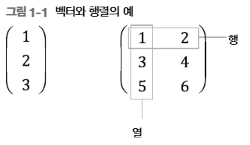   
- 그림처럼 벡터는 1차원 배열로, 행렬은 2차원 ㅂ열로 표현할 수 있음
- 행렬에서는 가로줄을 행(row)이라 하고, 세로줄을 열(column)이라 함
- 그래서 그림의 행렬은 '3행 2열의 행렬'이라 하고 '3 X 2 행렬'이라고 씀   

> 벡터와 행렬을 확장하여 숫자 집합을 N차원으로 표현한 것도 생각할 수 있음 - 이를 일반적으로 텐서라고 함   

벡터는 단순한 개념이지만 이를 표현하는 방법이 두 가지이므로 주의해야 함   
- 하나는 숫자들을 세로로 나열하는 방법(열벡터)
- 다른 하나는 가로로 나열하는 방법(행벡터)   
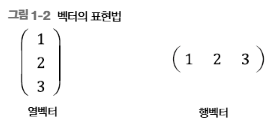   
- 수학과 딥러닝 등 많은 분야에서 '열벡터'방식을 선호하지만, 이 책에서는 구현 편의를 고려해 '행벡터'로 다룸 (매번 행벡터임을 명시함)   
- 또한 수식에서의 벡터나 행렬은 **x** 와 **W** 처럼 굵게 표기하여 단일 원소로 이루어진 스칼라 값과 구별함   

> 파이썬으로 구현할 때 벡터를 '행벡터'로 취급할 경우, 벡터를 가로 방향 '행렬'로 변환해 사용하면 명확해짐   
> 예컨대 원소 수가 N개인 벡터라면 1 X N 형상의 행렬로 처리함   

행렬을 취급할 때의 단골 라이브러리인 넘파이를 이용하여 벡터와 행렬을 생성해보기

In [1]:
import numpy as np

x = np.array([1, 2, 3])
print(x.__class__)  # 클래스 이름 표시
print(x.shape)
print(x.ndim)

W = np.array([[1, 2, 3], [4, 5, 6]])
print(W.__class__)
print(W.shape)
print(W.ndim)

<class 'numpy.ndarray'>
(3,)
1
<class 'numpy.ndarray'>
(2, 3)
2


- 이 코드에서 보듯 벡터와 행렬은 np.array() 메서드로 생성할 수 있음   
- 이 메서드는 넘파이의 다차원 베열 클래스인 np.ndarray 클래스를 생성함 
- np.ndarray 클래스에는 다양한 편의 메거드와 인스턴스 변수가 준비되어 있으며, 앞의 예에서는 인스턴스 변수 중 shape와 ndim을 이용함
    - shape는 다차원 배열의 형상
    - ndim은 차원의 수
- 앞의 결과를 보면 x는 1차원 배열이며 원소 수가 3개인 벡터임을 알 수 있음
- W는 2차원 배열이며 2 X 3(2행 3열) 행렬임을 알 수 있음

### 행렬의 원소별 연산

이번에는 벡터와 행렬을 사용해 간단한 계산을 해봄   

먼저 '원소별(element-wise) 연산'

In [2]:
W = np.array([[1, 2, 3], [4, 5, 6]])
X = np.array([[0, 1, 2,], [3, 4, 5]])

print(W + X)
print(W * X)

[[ 1  3  5]
 [ 7  9 11]]
[[ 0  2  6]
 [12 20 30]]


- 다차원 넘파이 배열의 사칙연산 중 더하기와 곱하기를 해봄
- 이렇게 하면 피연산자인 다차원 배열들에서 서로 대응하는 원소끼리(각 원소가 독립적으로) 연산이 이루어짐
- 이것이 넘파이 배열의 '원소별 연산'

### 브로드캐스트

넘파이의 다차원 배열에서는 형상이 다른 배열끼리도 연산할 수 있음

In [3]:
A = np.array([[1, 2], [3, 4]])
print(A * 10)

[[10 20]
 [30 40]]


- 이 계산에서는 2 X 2 행렬 A에 10이라는 슽칼라 값을 곱함
- 이렇게 하면 아래 그림처럼 스칼라 값 10이 2 X 2 행렬로 확장된 후에 원소별 연산을 수행함 - 이 기능을 브로드캐스트(broadcast)라 함   
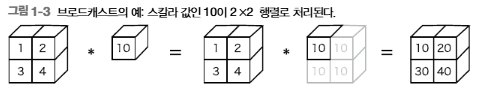   

브로드캐스트의 또 다른 예   
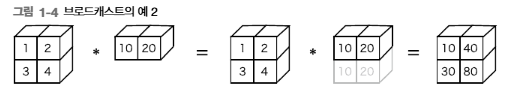   
- 이 계산에서는 그림처럼 1차원 배열인 b가 2차원 배열 A와 형상이 같아지도록 '영리하게' 확장됨   

이처럼 넘파이는 브로드캐스트라는 기능을 제공하여 형상이 다른 배열끼리의 연산을 영리하게 수행할 수 있음   

> 넘파이의 브로드캐스트가 효과적으로 동작하려면 다차원 배열의 형상이 몇 가지 규칙을 충족해야 함

In [4]:
A = np.array([[1, 2], [3, 4]])
b = np.array([10, 20])
print(A * b)

[[10 40]
 [30 80]]


### 백터의 내적과 행렬의 곱

우선 벡터의 내적은 수식으로는 다음과 같음   
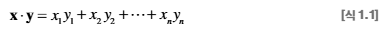   
- 여기에서는 2개의 벡터 이 있다고 가정함
- 그리고 식에서 보듯, 벡터의 내적은 두 벡터에서 대응하는 원소들의 곱을 모두 더한 것   

> 벡터의 내적은 직관적으로는 '두 벡터가 얼마나 같은 방향을 향하고 있는가'를 나타냄   
> 벡터의 길이가 1인 경우로 한정하면, 완전히 같은 방향을 향하는 두 벡터의 내적은 1이 됨   
> 반대로, 반대 방향을 향하는 두 벡터의 내적을 -1   

계속해서 행렬의 곱을 살펴보면   
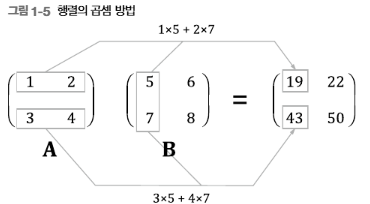   
- 행렬의 곱은 위 그림의 순서로 계산함
- 그림처럼 행렬의 곱은 '왼쪽 행렬의 행벡터(가로 방향)'와 '오른쪽 행렬의 열벡터(세로 방향)'의 내적(원소별 곱의 합)으로 계산함   
- 그리고 계산 결과는 새로운 행렬의 대응하는 원소에 저장됨
- 예를 들어 A의 1행과 B의 1열의 계산 결과는 1행 1열 위치의 원소가 되고, A의 2행과 B의 1열의 계산 결과는 2행 1열 위치의 원소가 됨   

그럼 벡터의 내적과 행렬의 곱을 파이썬으로 파이썬으로 구현해보기   
넘파이의 np.dot()과 np.matmul() 메서드를 이용하면 쉽게 구현할 수 있음

In [5]:
# 벡터의 내적
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print(np.dot(a, b))

# 행렬의 곱
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
print(np.matmul(A, B))

32
[[19 22]
 [43 50]]


- 사실 벡터의 내적과 행렬의 곱 모두에 np.dot()을 사용할 수 있음   
- np.dot(x, y)의 인수가 모두 1차원 배열이면 벡터의 내적을 계산하고, 2차원 배열이면 행렬의 곱을 계산함
- 다만, 가능하면 둘을 구분하여 코드의 논리와 의도를 명확히 해주는 게 좋음   

np.dot()과 np.matmul() 외에도 넘파이에는 행렬 계산을 도와주는 편의 메서드가 많이 준비되어 있음   
그 메서드들을 잘 다루면 신경망 구현도 막힘없이 진행할 수 있을 것   

> 넘파이를 익히는 데는 실제로 코딩해보며 연습하는 방법이 가장 좋음   
> 넘파이 경험을 쌓고 싶다면 '100 numpy exercises' 사이트를 추천함   
> 넘파이 연습 문제가 100개나 있으니 꼭 도전해보기

### 행렬 형상 확인

행렬이나 벡터를 사용해 계산할 때는 그 '형상(shape)'에 주의해야 함   
이번 절에서는 행렬의 곱을 형상에 주목해 다시 확인해봄   

행렬 곱의 계산 순서는 앞에서 설명했지만, 이때 아래 그림처럼 '형상 확인'이 중요함   
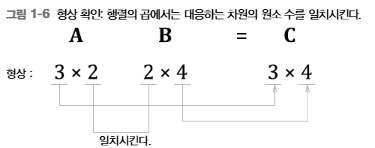   
- 그림은 3 X 2 행렬 A와 2 X 4 행렬 B를 곱하여 3 X 4 행렬 C를 만드는 예
- 이때 이 그림처럼 행렬 A와 B가 대응하는 차원의 원소 수가 같아야 함
- 그리고 결과로 만들어진 행렬 C의 형상은 A의 행 수와 B의 열 수가 됨 - 이것이 행렬의 '형상 확인'   

> 행렬의 곱 등 행렬을 계산할 때는 형상 확인이 중요함   
> 그래야 신경망 구현을 부드럽게 진행할 수 있음

## 신경망의 추론   

이제 신경망을 복습할 차례   
신경망에서 수행하는 작업은 두 단계로 나눌 수 있음   
- 학습
- 추론   

이번 절에서는 신경망 추론에 집중하고, 학습은 다음 절에서 다룸

### 신경망 추론 전체 그림

신경망은 간단히 말하면 단순한 '함수'라 할 수 있음   
함수란 무엇인가를 입력하면 무엇인가를 출력하는 변환기   
다시말해 신경망도 함수처럼 입력을 출력으로 변환함   

- 이번 절에서는 2차원 데이터를 입력하여 3차원 데이터를 출력하는 함수를 예로 듦
- 이 함수를 신경망으로 구현하려면 **입력층(input layer)** 에는 뉴런 2개를, **출력층(output layer)** 에는 3개를 각각 준비함   
- 그리고 **은닉층(hidden layer)**(혹은 **중간층**)에도 적당한 수의 뉴런을 배치함
- 이번 예에는 은닉층에 뉴런 4개를 두기로 함
- 그러면 이 신경망은 아래 그림처럼 그릴 수 있음   
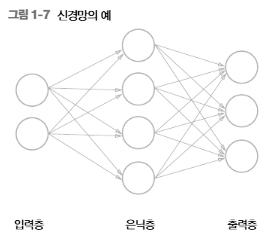   
- 그림에서는 뉴런은 ○로, 그 사이의 연결을 화살표로 나타냄 
- 이때 화살표에는 **가중치(weight)** 가 존재하여, 그 가중치와 뉴런의 값을 각각 곱해서 그 합이 다음 뉴런의 입력으로 쓰임
- (정확히는 그 합에 활성화 함수(activation function)를 적용한 값이 다음 뉴런의 입력이 됨)
- 또, 이때 각 층에서는 이전 뉴런의 값에 영향받지 않는 '정수'도 더해짐   
- 이 정수는 **편향(bias)** 이라고 함
- 덧붙여 위 그림의 신경망은 인접하는 층의 모든 뉴런과 연결(화살표로 이어짐)되어 있다는 뜻에서 **완전연결계층(fully connected layer)** 이라고 함   

> 위 그림의 신경망은 총 3층 구성이지만, 가중치를 지니는 층은 사실 2개뿐   
> 그래서 이 책에서는 이러한 신경망을 '2층 신경망'이라고 부름   
> 문헌에 따라서는 그림과 같은 구성을 '3층 신경망'이라고 하는 경우도 있으니 주의   

그럼 그림의 신경망이 수행하는 계산을 수식으로 나타내보기   
여기에서는 입력층의 데이터를 (x1, x2)로 쓰고, 가중치는 w11과 w21으로, 편향은 b1으로 씀   
그러면 그림의 은닉층 중 첫 번째 뉴런은 다음과 같이 계산할 수 있음   
   
- 식과 같이 은닉층의 뉴런은 가중치의 합으로 계산됨
- 이런 식으로 가중치와 편향의 값을 바꿔가며 위 식의 계산을 뉴런의 수만큼 반복하면 은닉층에 속한 모든 뉴런의 값을 구할 수 있음

가중치와 편향에는 첨자(인덱스)가 붙음   
이 첨자를 붙이는 규칙('11'이나 '12' 등을 어떻게 설정하느냐 하는 규칙)은 중요하지 않음   
중요한 것은 그것이 '가중치 합'으로 계산된다는 것, 그리고 그 값은 행렬의 곱으로 한꺼번에 계산할 수 있다는 사실   
실제로 완전연결계층이 수행하는 변환은 행렬의 곱을 이용해 다음처럼 정리해 쓸 수 있음   
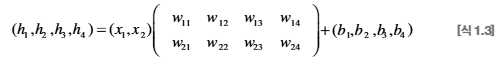   
- 여기에서 은닉층의 뉴런들은 (h1, h2, h3, h4)로 정리되며, 1 X 4 행렬로 간주할 수 있음(혹은 '행벡터'로 취급함)
- 또 입력 (x1, x2)는 1 X 2 행렬이며, 가중치는 2 X 4 행렬, 편향은 1 X 4 행렬에 대응함   
- 그러면 위 식은 다음처럼 간소화할 수 있음   
   
- 여기서 x는 입력, h는 은닉층의 뉴헌, W는 가중치, b는 편향을 뜻함
- 이 기호 각각은 모두 행렬
- 그리고 위 식의 각 행렬의 형상을 잘 보면 아래 그림처럼 변환된다는 사실을 알 수 있음   
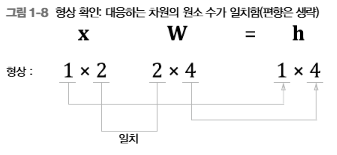   
- 그림에서 보듯, 행렬의 곱에서는 대응하는 차원의 원소 수가 일치해야 함   
- 이처럼 행렬의 형상을 살펴보면 올바른 변환인지를 확인할 수 있음   

> 행렬의 곱 계산에서는 행렬의 형상 확인이 중요함   
> 형상을 보면 그 계산이 올바른 계산인지, 적어도 계산이 성립하는지 여부를 확인할 수 있음   

이것으로 완전연결계층에 의한 변환을 행렬로 정리하고 계산해봤음   
그런데 지금까지 수행한 변환은 하나의 샘플 데이터(입력 데이터)만을 대상으로 했음   
하지만 신경망이나 학습에서는 다수의 샘플 데이터(미니배치(minibatch))를 한꺼번에 처리함   
이렇게 하려면 행렬 x의 행 각각에 샘플 데이터를 하나씩 저장해야 함   
- 예컨대 N개의 샘플 데이터를 미니배치로 한꺼번에 처리한다면 아래 그림처럼 됨(행렬의 형상에 주목)   
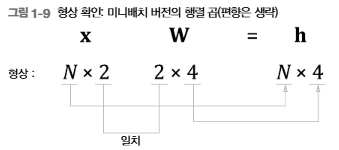   
- 그림과 같이 형상 확인을 통해 각 미니배치가 올바르게 변환되었는지를 알 수 있음   
- 이때 N개의 샘플 데이터가 한꺼번에 완전연결계층에 의해 변환되고, 은닉층에는 N개 분의 뉴런이 함께 계산됨   

그럼 완전연결계층에 의한 변환의 미니배치 버전을 파이썬으로 구현해보면

In [6]:
import numpy as np

W1 = np.random.randn(2, 4)  # 가중치
b1 = np.random.randn(4)  # 편향
x = np.random.randn(10, 2)  # 입력

h = np.matmul(x, W1) + b1
print(h)

[[ 1.22797831e+00  7.26092026e-01  1.78237912e+00  4.23171969e-01]
 [ 2.19832186e-01 -8.28794702e-01  1.55606613e+00  1.70058891e-03]
 [-3.52851746e-01 -9.82243712e-01 -7.11418774e-02 -7.81075295e-01]
 [ 7.93230207e-01  3.80376145e-01  1.01780675e+00 -4.03626916e-04]
 [ 2.32477385e+00  1.92501878e+00  3.04030661e+00  1.24851574e+00]
 [ 3.79620186e-01 -8.90668748e-01  2.22505815e+00  2.98049768e-01]
 [ 5.89358269e-01 -1.84134175e-01  1.48555922e+00  1.00547825e-01]
 [ 1.87129371e+00  1.80276329e+00  1.75333444e+00  6.29230162e-01]
 [ 1.24039353e+00  6.04841697e-01  2.07346995e+00  5.32890928e-01]
 [ 2.93296974e+00  2.94177037e+00  3.01519392e+00  1.44417564e+00]]


- 이 예에서는 10개의 샘플 데이터 각각을 완전연결계층으로 변환시켰음
- 이때 x의 첫 번째 차원이 각 샘플 데이터에 해당함
- 예컨대 x[0]는 0번째 입력 데이터, x[1]은 첫 번째 입력 데이터
- 마찬가지로 h[0]는 0번째 데이터의 은닉층 뉴런, h[1]은 1번째 데이터의 은닉층 뉴런이 저장됨   

> 위 코드의 마지막 줄에서 편향 b1의 덧셈은 브로드캐스트됨   
> b1의 형상은 (4,)이지만 자동으로 (10, 4)로 복제되는 것   

그런데 완전연결계층에 의한 변환은 '선형' 변환   
여기에 '비선형' 효과를 부여하는 것이 바로 활성화 함수   
더 정확하게 말하면, 비선형 활성화 함수를 이용함으로써 신경망의 표현력을 높일 수 있음   
활성화 함수는 아주 다양하지만, 여기에서는 아래 식인 **시그모이드 함수(sigmoid function)** 를 사용함   
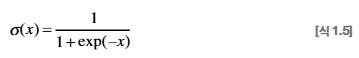   
- 시그모이드 함수는 아래 그림과 같은 알파벳 S자 모양의 곡선 함수   
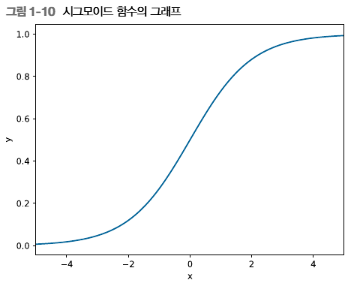   
- 시그모이드 함수는 임의의 실수를 입력받아 0에서 1 사이의 실수를 출력함   

시그모이드 함수를 파이썬으로 구현해보면

In [7]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

- 위에 식을 그대로 구현한 코드이니 어려운 점은 없음   

이 시그모이드 함수를 사용하여 방금 전의 은닉층 뉴런을 변환해보면

In [8]:
a = sigmoid(h)
print(a)

[[0.77346454 0.67394711 0.85599039 0.60424202]
 [0.55473778 0.30389998 0.82578814 0.50042515]
 [0.41269105 0.27244681 0.48222203 0.31408818]
 [0.6885245  0.59396382 0.73454516 0.49989909]
 [0.91090812 0.87269705 0.95436219 0.77704282]
 [0.59378149 0.29097184 0.90247728 0.5739657 ]
 [0.64321789 0.45409608 0.8154108  0.5251158 ]
 [0.8666079  0.85848498 0.85237288 0.65231488]
 [0.77563251 0.64676323 0.88829773 0.63015712]
 [0.94945239 0.94987309 0.95325584 0.80910044]]


- 이로써 시그모이드 함수에 의해 비선형 변환이 가능했음
- 계속해서 이 활성화 함수의 출력인 a(이를 **활성화(activation)** 라고 함)를 또 다른 완전연결계층에 통과시켜 변환함
- 지금 예에서는 은닉층의 뉴런은 4개, 출력층의 뉴런은 3개이므로 완전연결계층에 사용되는 가중치 행렬은 4 X 3 형상으로 설정해야 함 - 이것으로 출력층의 뉴런을 얻을 수 있음   

여기까지가 신경망의 추론   
그럼 지금까지의 내용을 종합해 파이썬으로 작성해보면

In [9]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.random.randn(10, 2)

W1 = np.random.randn(2, 4)
b1 = np.random.randn(4)

W2 = np.random.randn(4, 3)
b2 = np.random.randn(3)

h = np.matmul(x, W1) + b1
a = sigmoid(h)
s = np.matmul(a, W2) + b2
print(s)

[[-0.71172092  1.13678091 -0.62246271]
 [-0.61502006 -0.46923964 -0.26319377]
 [-0.40776229 -0.05007489  0.59943753]
 [-0.66195264  0.85152171 -0.31474249]
 [-0.63229529 -0.37299876 -0.15654477]
 [-0.72584144 -0.25608672 -0.46952237]
 [-0.6394319   0.96352022 -0.29446172]
 [-0.71029198  0.58689602 -0.35788004]
 [-0.78667582  0.29324826 -0.5540386 ]
 [-0.57854975 -0.07741404  0.17631488]]


- 여기에서 x의 형상은 (10, 2) - 2차원 데이터 10개가 미니배치로 처리된다는 뜻
- 그리고 최종 출력인 s의 형상은 (10, 3)이 됨 - 이것은 10개의 데이터가 한꺼번에 처리되었고, 각 데이터는 3차원 데이터로 변환되었다는 뜻   

그런데 이 신경망은 3차원 데이터를 출력함   
따라서 각 차원의 값을 이용하여 3 클래스 분류를 할 수 있음   
이 경우, 출력된 3차원 벡터의 각 차원은 각 클래스에 대응하는 '점수(score)'가 됨(첫 번째 뉴런이 첫 번째 클래스, 두 번째 뉴런이 두 번째 클래스, ...)   
실제로 분류를 한다면 출력층에서 가장 큰 값을 내뱉는 뉴런에 해당하는 클래스가 예측 결과가 되는 것   

> 점수란 '확률'이 되기 전의 값   
> 점수가 높을수록 그 뉴런에 해당하는 클래스의 확률도 높아짐   
> 점수를 소프트맥스 함수(softmax function)에 입력하면 확률을 얻을 수 있음   

이상으로 신경망의 추론을 구현해봤음   
다음 절에서는 지금까지 수행한 처리를 하나의 '계층'으로 추상화한 파이썬 클래스를 구현해봄

### 계층으로 클래스화 및 순전파 구현

그럼 신경망에서 하는 처리를 계층(layer)으로 구현해보기   
여기에서는 완전연결계층에 의한 변환을 Affine 계층으로, 시그모이드 함수에 의한 변환을 Sigmoid 계층으로 구현함   
참고로 완전연결계층에 의한 변환은 기하학에서의 affine 변환에 해당하기 때문에 Affine 계층이라고 이름 지음   
또한 각 계층은 파이썬 클래스로 구현하며, 기본 변환을 수행하는 메서드의 이름은 forward()로 함   

> 신경망 추론 과정에서 하는 처리는 신경망의 **순전파(forward propagation)** 에 해당함   
> 순전파란 말 그대로 입력층에서 출력층으로 향하는 전파   
> 순전파 때는 신경망을 구성하는 각 계층이 입력으로부터 출력 방향으로 처리 결과를 차례로 전파해감   
> 나중에 살펴볼 신경망 학습에서는 데이터(기울기)를 순전파와는 반대 방향으로 전파함 - 이것을 **역전파(backward propagation)** 라고 함   

신경망에는 다양한 계층이 등장하는데, 여기선 이 계층들을 모두 파이썬 클래스로 구현함   
이렇게 모듈화를 해두면 레고 블록을 조합하듯 신경망을 구축할 수 있음   
이 책에서는 이러한 계층을 구현할 때 다음의 '구현 규칙'을 따름   
- 모든 계층은 forward()와 backward() 메서드를 가짐
- 모든 계층은 인스턴스 변수인 params와 grads를 가짐   

이 구현 규칙을 간단히 설명해보면   
- forward()와 backward() 메서드는 각각 순전파와 역전파를 수행함
- params는 가중치와 편향 같은 매개변수를 담는 리스트(매개변수는 여러 개가 있을 수 있어서 리스트에 보관함)
- grads는 params에 저장된 각 매개변수에 대응하여, 해당 매개변수의 기울기를 보관하는 리스트   

> 이 구현 규칙에 따라 구현하면 일관되고 확장성이 좋아짐   
> 왜 이 규칙을 따르는지, 또 이 규칙이 얼마나 유효한지는 나중에 밝혀짐   

이번 절에서는 순전파만 구현할 것이므로 앞의 구현 규칙 중 다음 두 사항만 적용함   
- 각 계층은 forward() 메서드만 가짐
- 매개변수들은 params 인스턴스 변수에 보관함   

이 구현 규칙에 따라 가장 먼저 Sigmoid 계층을 구현해보면

In [10]:
import numpy as np

class Sigmoid:
    def __init__(self):
        self.params = []
    
    def forward(self, x):
        return 1 / (1 + np.exp(-x))

- 이와 같이 시그모이드 함수를 클래스로 구현했으며, 주 변환 처리는 forward(x) 메서드가 담당함
- Sigmoid 계층에는 학습하는 매개변수가 따로 없으므로 인스턴스 변수인 params는 빈 리스트로 초기화함   

그럼 계속해서 완전연결계층인 Affine 계층을 구현해보면

In [11]:
class Affine:
    def __init__(self, W, b):
        self.params = [W, b]
    
    def forward(self, x):
        W, b = self.params
        out = np.matmul(x, W) + b
        return out

- Affine 계층은 초기화될 때 가중치와 편향을 받음
- 즉, 가중치와 편향은 Affine 계층의 매개변수이며(이 두 매개변수는 신경망이 학습될 때 수시로 갱신됨), 리스트인 params 인스턴스 변수에 보관함
- 다음으로 forward(x)는 순전파 처리를 구현함   

> 이 책의 예제 코드는 앞의 '구현 규칙'을 따르므로, 모든 계층에는 학습해야 하는 매개변수가 반드시 인스턴스 변수인 params에 존재하게 됨   
> 이 덕분에 신경망의 모든 매개변수를 간단하게 정리할 수 있고, 자연스럽게 매개변수 갱신 작업이나 매개변수를 파일로 저장하는 일이 쉬워짐   

그러면 앞에서 구현한 계층을 사용해 신경망의 추론 처리를 구현해보기   
아래 그림처럼 구성된 신경망을 구현할 것   
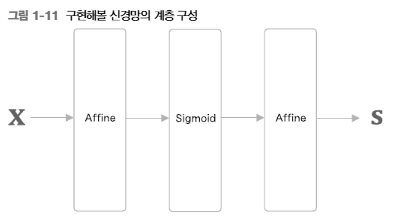   
- 그림에서 보듯, 이번 예에서는 입력 x가 Affine 계층, Sigmoid 계층, Affine 계층을 차례로 거쳐 점수인 s를 출력하게 됨
- 이 신경망을 TwoLayerNet 이라는 클래스로 추상화하고, 주 추론 처리는 predict(x) 메서드로 구현함   

> 신경망을 그릴 때, 지금까지는 '뉴런 관점'의 그림을 이용했지만   
> 이후로는 위 그림처럼 '계층 관점'으로 표현할 예정   

그럼 TwoLayerNet을 구현해보기

In [12]:
class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size):
        I, H, O = input_size, hidden_size, output_size

        # 가중치와 편향 초기화
        W1 = np.random.randn(I, H)
        b1 = np.random.randn(H)
        W2 = np.random.randn(H, O)
        b2 = np.random.randn(O)

        # 계층 생성
        self.layers = [Affine(W1, b1), Sigmoid(), Affine(W2, b2)]

        # 모든 가중치를 리스트에 모음
        self.params = []
        for layer in self.layers:
            self.params += layer.params
    
    def predict(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

- 이 클래스의 초기화 메서드(\_\_init__)는 먼저 가중치를 초기화하고 3개의 계층을 생성함
- 마지막으로는 학습해야 할 가중치 매개변수들을 params 리스트에 저장함
- 모든 계층은 자신의 학습 매개변수들을 인스턴스 변수인 params에 보관하고 있으므로, 이 변수들을 더해주기만 하면 됨
- 이로써 TwoLayerNet의 params 변수에는 모든 학습 매개변수가 담기게 됨
- 이처럼 매개변수들을 하나의 리스트에 보관하면 '매개변수 갱신'과 '매개변수 저장'을 손쉽게 처리할 수 있음   

파이썬에서 + 연산자는 리스트들을 결합해줌   
예시를 보면

In [13]:
a = ['A', 'B']
a += ['C', 'D']
print(a)

['A', 'B', 'C', 'D']


보다시피 리스트끼리 더하면 리스트들이 결합됨   
앞서의 TwoLayerNet 구현에서는 각 계층의 params 리스트를 더해주는 것만으로, 모든 학습 매개변수를 하나의 리스트에 담은 것   

그럼 TwoLayerNet 클래스를 이용해 신경망의 추론을 수행해보면

In [14]:
x = np.random.randn(10, 2)
model = TwoLayerNet(2, 4, 3)
s = model.predict(x)

print(s)

[[ 0.77629681  1.50766191 -3.64338204]
 [ 0.40953127  1.17952118 -3.19194455]
 [ 0.12993285  0.92527396 -2.80132483]
 [ 0.21119045  1.11310251 -3.08173157]
 [-0.63128798 -0.03435653 -1.52586444]
 [ 0.71769933  1.5880581  -3.74100999]
 [-0.25772034  0.24577388 -1.79267127]
 [ 0.60892537  1.40706798 -3.52115807]
 [ 0.52777095  1.6490587  -3.87903721]
 [ 0.82341475  1.56337479 -3.69709171]]


- 이상으로 입력 데이터 x에 대한 점수(s)를 구할 수 있었음
- 이처럼 계층을 클래스로 만들어두면 신경망을 쉽게 구현할 수 있음
- 또한 학습해야 할 모든 매개변수가 model.params 라는 하나의 리스트에 모여 있으므로, 이어서 설명할 신경망 학습이 한결 수월해짐

## 신경망의 학습

학습되지 않은 신경망은 '좋은 추론'을 해낼 수 없음   
그래서 학습을 먼저 수행하고, 그 학습된 매개변수를 이용해 추론을 수행하는 흐름이 일반적   
추론이란 앞 절에서 본 것 같은 다중 클래스 분류 등의 문제에 답을 구하는 작업   
한편, 신경망의 학습은 최적의 매개변수 값을 찾는 작업   

이번 절에서는 신경망의 학습에 대해 살펴봄

### 손실 함수

신경망 학습에는 학습이 얼마나 잘 되고 있는지를 알기 위한 '척도'가 필요   
일반적으로 학습 단계의 특정 시점에서 신경망의 성능을 나타내는 척도로 **손실(loss)** 을 사용함   
손실은 학습 데이터(학습 시 주어진 정답 데이터)와 신경망이 예측한 결과를 비교하여 예측이 얼마나 나쁜가를 산출한 단일 값(스칼라)   

신경망의 손실은 **손실 함수(loss function)** 를 사용해 구함   
다중 클래스 분류(multi-class classification) 신경망에서는 손실 함수로 흔히 **교차 엔트로피 오차(Cross Entropy Error)를 이용함   
교차 엔트로피 오차는 신경망이 출력하는 각 클래스의 '확률'과 '정답 레이블'을 이용해 구할 수 있음   

그럼 지금까지 다뤄 온 신경망에서 손실을 구해보기   
우선 앞 절의 신경망에 Softmax 계층과 Cross Entropy Error 계층을 새로 추가함   
(Softmax 계층은 소프트맥스 함수를, Cross Entropy Error 계층은 교차 엔트로피 오차를 구하는 계층)   
이 신경망의 구성을 '계층 관점'에서 그리면 아래처럼 됨   
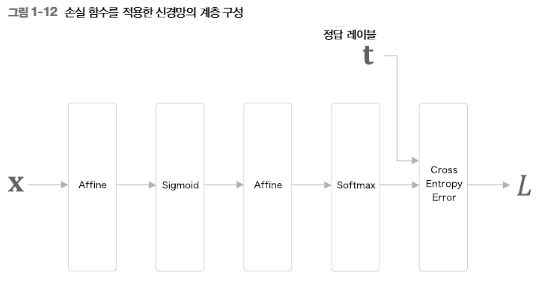   
- 그림의 x는 입력 데이터, t는 정답 레이블, L은 손실을 나타냄   
- 이때 Softmax 계층의 출력은 확률이 되어, 다음 계층인 Cross Entropy Error 계층에는 확률과 정답 레이블이 입력됨   

이어서 소프트맥스 함수와 교차 엔트로피 오차에 관해 알아봄   
우선 소프트맥스 함수를 식으로 쓰면 다음과 같음   
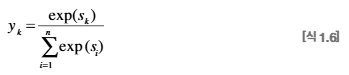   
- 위 식은 출력이 총 n개일 때, k번째의 출력 yk를 구하는 계산식   
- yk는 k번째 클래스에 해당하는 소프트맥스 함수의 출력   
- 이 식에서 보듯 소프트맥스 함수의 분자는 점수 sk의 지수 함수이고, 분모는 모든 입력 신호의 지수 함수의 총합   

소프트맥스 함수의 출력의 각 원소는 0.0 이상 1.0 이하의 실수, 그리고 그 원소들을 모두 더하면 1.0이 됨 - 이것이 소프트맥스의 출력을 '확률'로 해석할 수 있는 이유   
소프트맥스의 출력인 이 '확률'이 다음 차례인 교차 엔트로피 오차에 입력됨   
이때 교차 엔트로피 오차의 수식은 다음과 같음   
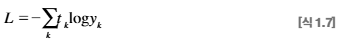   
- 여기서 tk는 k번째 클래스에 해당하는 정답 레이블
- log는 네이피어 상수(혹은 오일러의 수) e를 밑으로 하는 로그 (정확하게는 loge로 표기함)
- 정답 레이블은 t = [0,0,1]과 같이 원핫 벡터로 표기함   

> 원핫 벡터(one hot vector)란 단 하나의 원소만 1이고, 그 외에는 0인 벡터   
> 여기서 1인 원소가 정답 클래스에 해당함   
> 따라서 위 식은 실질적으로 정답 레이블이 1의 원소에 해당하는 출력의 자연로그(log)를 계산할 뿐(다른 원소들은 tk가 0이므로 계산 결과에 영향을 주지 못함)   

나아가 미니배치 처리를 고려하면 교차 엔트로피 오차의 식은 다음처럼 됨   
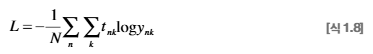   
- 이 식에서 데이터는 N개이며, tnk는 n번째 데이터의 k차원째의 값을 의미, ynk는 신경망의 출력, tnk는 정답 레이블   
- 위 식은 조금 복잡해 보이지만, 하나의 데이터에 대한 손실 함수를 나타낸 전의 식을 단순히 데이터 N개짜리로 확장했을 뿐 
- 다만, 이 식에서는 N으로 나눠서 1개당의 '평균 손실 함수'를 구함   
- 이렇게 평균을 구함으로써 미니배치의 크기에 관계없이 항상 일관된 척도를 얻을 수 있음   

이 책에서는 소프트맥스 함수와 교차 엔트로피 오차를 계산하는 계층을 Softmax with Loss 계층 하나로 구현함 (이 두 계층을 통합하면 역전파 계산이 쉬워짐)   
따라서 우리의 (학습 시) 신경망의 계층 구성은 아래 그림처럼 됨   
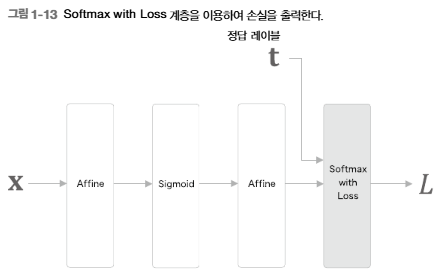   

파이썬으로 구현해보면

In [15]:
def softmax(x):
    if x.ndim == 2:
        x = x - x.max(axis=1, keepdims=True)
        x = np.exp(x)
        x /= x.sum(axis=1, keepdims=True)
    elif x.ndim == 1:
        x = x - np.max(x)
        x = np.exp(x) / np.sum(np.exp(x))

    return x


def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)
        
    # 정답 데이터가 원핫 벡터일 경우 정답 레이블 인덱스로 변환
    if t.size == y.size:
        t = t.argmax(axis=1)
             
    batch_size = y.shape[0]

    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

class SoftmaxWithLoss:
    def __init__(self):
        self.params, self.grads = [], []
        self.y = None  # softmax의 출력
        self.t = None  # 정답 레이블

    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)

        # 정답 레이블이 원핫 벡터일 경우 정답의 인덱스로 변환
        if self.t.size == self.y.size:
            self.t = self.t.argmax(axis=1)

        loss = cross_entropy_error(self.y, self.t)
        return loss

    def backward(self, dout=1):
        batch_size = self.t.shape[0]

        dx = self.y.copy()
        dx[np.arange(batch_size), self.t] -= 1
        dx *= dout
        dx = dx / batch_size

        return dx

### 미분과 기울기

신경망 학습의 목표는 손실을 최소화하는 매개변수를 찾는 것   
이때 중요한 것이 '미분'과 '기울기'   

어떤 함수 y = f(x)가 있다고 했을 때   
x에 관한 y의 미분은    
이 가 의미하는 것은 x의 값을 '조금' 변화시켰을 때(더 정확하게는 그 '조금의 변화'를 극한까지 줄일 때) y값이 얼마나 변하는가 하는 '변화의 정도'   

y = x^2 이라는 함수를 예로 살펴보면   
이 함수의 미분을 해석적으로 구하면 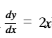가 됨   
이 미분 결과는 각 x에서의 변화의 정도를 뜻하며, 아래 그림에서 보듯 함수의 '기울기'에 해당   
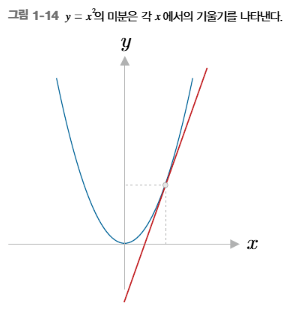   
- 그림에서는 x라는 변수 하나에 대해 미분을 구했지만, 여러 개의 변수(다변수)라도 마찬가지로 미분할 수 있음
- 예를 들어 L은 스칼라, x는 벡터인 함수 L=f(x)가 있으면
- 이때 (x의 i번째 원소인) xi에 대한 L의 미분은 로 쓸 수 있음   
- 그리고 벡터 x의 다른 원소의 미분도 구할 수 있고, 이를 다음과 같이 정리할 수 있음   
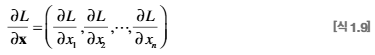   

이처럼 벡터의 각 원소에 대한 미분을 정리한 것이 **기울기(gradient)**   

벡터와 마찬가지로, 행렬에서도 기울기를 생각할 수 있음   
예컨대 W가 m X n 행렬이라면, L = g(W) 함수의 기울기는 다음과 같이 쓸 수 있음   
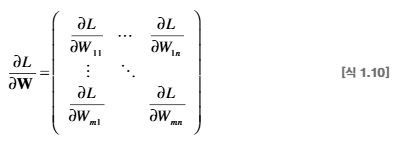   
- 위 식처럼 L의 W에 대한 기울기를 행렬로 정리할 수 있음(정확하게는 행렬의 기울기를 위와 같이 정의함)
- 여기에서 중요한 점은 W와 의 형상이 같다는 것
- 그리고 '행렬과 그 기울기의 형상이 같다'라는 이 성질을 이용하면 매개변수 갱신과 연쇄 법칙을 쉽게 구현할 수 있음   

> 엄밀하게 말하면, 이 책에서 사용하는 '기울기'는  수학에서 말하는 기울기와는 다름   
> 수학에서의 기울기는 벡터에 대한 미분으로 한정됨   
> 딥러닝에서는 행렬이나 텐서에 대해서도 미분을 정의하고, 그것을 기울기라 부르는 것이 일반적

### 연쇄 법칙

학습 시 신경망은 학습 데이터를 주면 손실을 출력함   
여기서 우리가 얻고 싶은 것은 각 매개변수에 대한 손실의 기울기   
그 기울기를 얻을 수 있다면, 그것을 사용해 매개변수를 갱신할 수 있기 때문   
신경망의 기울기를 구할 때 **오차역전파법(back-propagation)** 이 사용됨   

오차역전파법을 이해는 열쇠는 **연쇄 법칙(chain rule)**   
연쇄법칙이란 합성함수에 대한 미분의 법칙(합성함수란 여러 함수로 구성된 함수)   

연쇄 법칙을 자세히 알아보면   
- 예를 들어 y = f(x)와 z = g(y) 라는 두 함수가 있을 때
- 그러면 z = g(f(x))가 되어, 최종 출력 z는 두 함수를 조합해 계산할 수 있음   
- 이때 합성함수의 미분(x에 대한 z의 미분)은 다음과 같이 구할 수 있음   
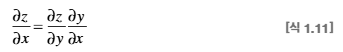   
- 식이 말하듯, x에 대한 z의 미분은 y = f(x)의 미분과 z = g(y)의 미분을 곱하면 구해짐
- 이것이 연쇄 법칙   

이 연쇄법칙이 중요한 이유는 우리가 다루는 함수가 아무리 복잡하다 하더라도, 즉 아무리 많은 함수를 연결하더라도, 그 미분은 개별 함수의 미분들을 이용해 구할 수 있기 때문   
달리 말하면, 각 함수의 국소적인 미분을 계산할 수 있다면 그 값들을 곱해서 전체의 미분을 구할 수 있음   

> 신경망은 여러 '함수'가 연결된 것이라고 생각할 수 있음   
> 오차역전파법은 그 여러 함수(신경망)에 대해 연쇄 법칙을 효율적으로 적용하여 기울기를 구해냄

### 계산 그래프

오차역전파법을 살펴보기 전에 그 준비 단계로 '계산 그래프'부터 설명   
계산 그래프는 계산 과정을 시각적으로 보여줌   
먼저 아래 그림처럼 아주 단순한 계산 그래프를 예로 보면   
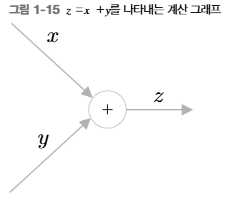   
- 그림에서 보듯 계산 그래프는 노드와 화살표로 그림
- 더하기를 '+' 노드로 나타냈고, 변수 x와 y를 해당 화살표 위에 썼음
- 이처럼 계산 그래프에서는 연산을 노드로 나타내고 그 처리 결과가 순서대로(이 예에서는 왼쪽에서 오른쪽으로) 흐름
- 이것이 계산 그래프의 순전파   
- 계산 그래프를 이용하면 계산을 시각적으로 파악할 수 있고, 그 기울기도 직관적으로 구할 수 있음   
- 여기서 중요한 점은 기울기가 순전파와 반대 방향으로 전파된다는 사실인데, 이 반대 방향의 전파가 '역전파'   

역전파를 설명하기 전에, 역전파가 이루어지는 전체 그림을 더 명확하게 그려보면   
지금 우리는 z = x + y라는 계산을 다루고 있지만, 이 계산 앞뒤로도 '어떤 계산'이 있다고 가정하고 최종적으로 스칼라 값인 L이 출력된다고 가정하면   
(신경망 학습에서 계산 그래프의 최종 출력은 손실이며, 그 값은 스칼라)   
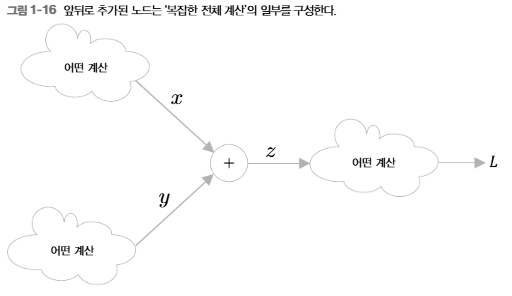   
- 우리 목표는 L의 미분(기울기)을 각 변수에 대해 구하는 것   
- 그러면 계산 그래프의 역전파는 아래 그림과 같이 그릴 수 있음   
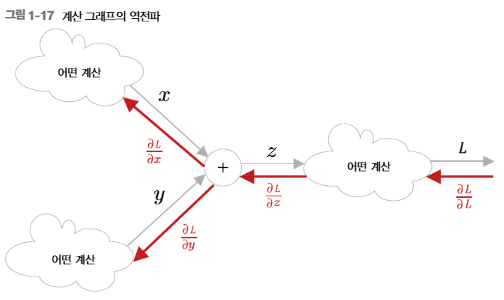   
- 그림처럼 역전파는 두꺼운(붉은) 화살표로 그리고, 화살표 아래에 '전파되는 값'을 씀
- 이때 '전파되는 값'은 최종 출력 L의 각 변수에 대한 미분   
- 이 예에서는 z에 대한 미분은 이고, x와 y에 대한 미분은 각각 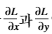   
- 그리고 여기서 다시 연쇄 법칙이 등장함
- 연쇄 법칙에 따르면 역전파로 흐르는 미분 값은 상류로부터 흘러온 미분과 각 연산 노드의 국소적인 미분을 곱해 계산할 수 있음(여기서 '상류'는 출력 쪽을 가리킴)
- 그러므로 이 예에서는 와 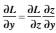가 됨   

그런데 우리는 지금 z = x + y의 덧셈 노드에서 이루어지는 연산을 다루고 있음   
따라서 과 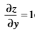이라는 결과를 (해석적으로) 구할 수 있음   
이 결과를 적용하면 덧셈 노드는 아래 그림처럼 상류로부터 받은 값에 1을 곱하여 하류로 기울기를 전파함   
즉, 상류로부터의 기울기를 그대로 흘리기만 함   
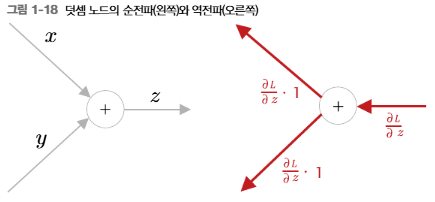   

이처럼 계산 그래프는 계산을 시각적으로 보여줌   
그리고 역전파에 의한 기울기 흐름을 살펴봄으로써, 그 도출 과정을 이해하는 데도 도움을 줌   

이어서 대표적인 연산 노드를 몇 가지 살펴볼 예정


#### 곱셈 노드

곱셈 노드는 z = x X y 연산을 수행함   
이때 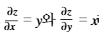라는 미분 결과를 각각 구할 수 있음   
따라서 곱셈 노드의 역전파는 아래 그림처럼 '상류로부터 받은 기울기'에 '순전파 시의 입력을 서로 바꾼 값'을 곱함(즉, 순전파 시 입력이 x면 y를 곱하고, y면 x를 곱함)   
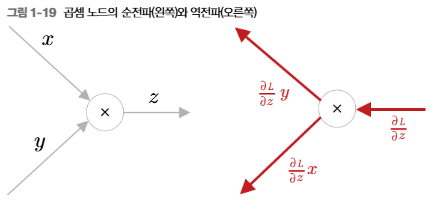   

참고로, 지금까지 살펴본 덧셈 노드와 곱셈 노드 설명에서는 값이 하나짜리 데이터만 예로 들었지만,   
벡터나 행렬 혹은 텐서 같은 다변수를 흘려도 문제 없음   
덧셈 노드(또는 곱셈 노드)를 흐르는 데이터가 텐서라면 텐서의 각 원소를 독립적으로 계산할 뿐   
다시 말해, 이 경우는 텐서의 다른 원소들과는 독립적으로, '원소별 연산'을 수행함   


#### 분기 노드

분기 노드는 아래 그림과 같이 분기하는 노드   
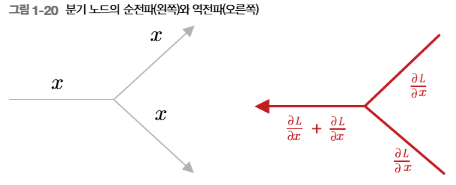   
- 분기 노드는 따로 그리지 않고 단순히 선이 두 개로 나뉘도록 그리는데, 이때 같은 값이 복제되어 분기함   
- 따라서 분기 노드를 '복제 노드'라고 할 수도 있음
- 그리고 그 역전파는 그림에서 보듯 상류에서 온 기울기들의 '합'이 됨


#### Repeat 노드

2개로 분기하는 분기 노드를 일반화하면 N개로의 분기(복제)가 되는데 이를 Repeat 노드라 함   
Repeat 노드의 예를 계산 그래프로 그리면   
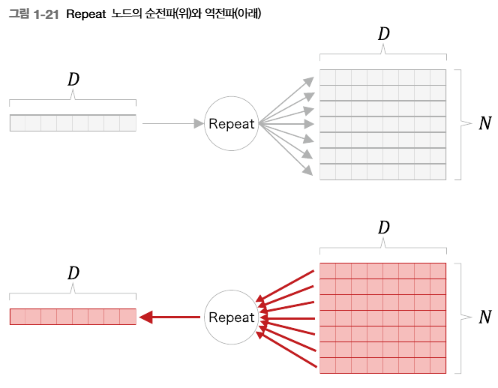   
- 그림은 길이가 D인 배열을 N개로 복제하는 예
- 이 Repeat 노드는 N개의 분기 노드로 볼 수 있으므로, 그 역전파는 N개의 기울기를 모두 더해 구할 수 있음   

코드로 나타내면

In [16]:
import numpy as np

D, N = 8, 7
x = np.random.randn(1, D)  # 입력
y = np.repeat(x, N, axis=0)  # 순전파

dy = np.random.randn(N, D)  # 무작위 기울기
dx = np.sum(dy, axis=0, keepdims=True)  # 역전파

- 여기서 np.repeat() 메서드가 원소 복제를 수행함
- 이 코드에서는 배열 x를 N번 복제하는데, 이때 axis를 지정하여 어느 축 방향으로 복제할지를 조정할 수 있음
- 또, 역전파에서는 총합을 구해야 하므로 np.sum() 메서드를 이용함, 이때도 axis 인수를 설정하여 어느 축 방향으로 합을 구할지 지정함
- 또한 인수로 keepdims=True를 설정하여 2차원 배열의 차원 수를 유지함
- 이 예에서는 keepdims가 True면 np.sum()의 결과의 형상은 (1, N)이 되며, False면 (N,)이 됨   

> 넘파이의 브로드캐스트는 배열의 원소를 복제하면, Repeat 노드를 사용하여 이 기능을 표현할 수 있음   


#### Sum 노드

Sum 노드는 범용 덧셈 노드   
예컨대 N X D 배열에 대해 그 총합을 0축에 대해 구하는 계산을 생각해보면   
이때 Sum 노드의 순전파와 역전파는 아래 그림처럼 됨   
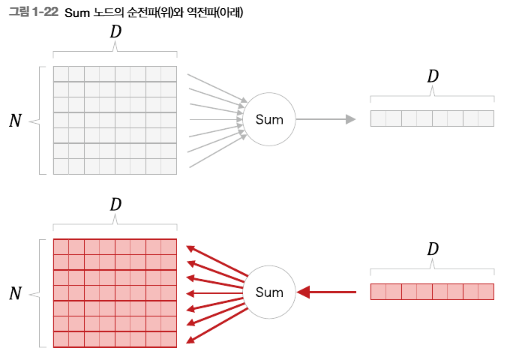   
- 그림에서 보듯, Sum 노드의 역전파는 상류로부터의 기울기를 모든 화살표에 분배함
- 덧셈 노드의 역전파를 자연스럽게 확장한 것

그럼 Sum 노드의 구현 예시를 보면

In [17]:
import numpy as np

D, N = 8, 7
x = np.random.randn(N, D)  # 입력
y = np.sum(x, axis=0, keepdims=True)  # 순전파

dy = np.random.randn(1, D)  # 무작위 기울기
dx = np.repeat(dy, N, axis=0)  # 역전파

- 보다시피 Sum 노드의 순전파는 np.sum() 메서드로, 역전파는 np.repeat() 메서드로 구현할 수 있음
- 여기서의 흥미로운 점은 Sum 노드와 Repeat 노드는 서로 '반대 관계'라는 것
- 반대 관계란 Sum 노드의 순전파가 Repeat 노드의 역전파가 되며, Sum 노드의 역전파가 Repeat 노드의 순전파가 된다는 뜻   


#### MatMul 노드

이 책에서는 행렬의 곱셈을 MatMul 노드('matrix Multiply'의 약자)로 표현함   
MatMul 노드의 역전파는 다소 복잡하므로 여기에서는 일반적인 설명을 한 후에 직관적인 이해를 돕는 설명을 덧붙임   

y = xW 라는 계산을 예로 들어 MatMul 노드를 설명   
여기서 x, W, y의 형상은 각각 1 X D, D X H, 1 X H (아래 그림)   
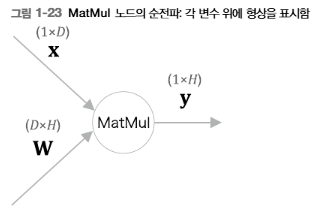   
- 이때 x의 i번째 원소에 대한 미분 은 다음과 같이 구함   
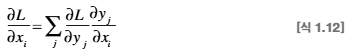   
- 이 식의 은 xi를 (조금) 변화시켰을 때 L이 얼마나 변할 것이가라는 '변화의 정도'를 나타냄   
- 여기서 xi를 변화시키면 벡터 y의 모든 원소가 변하고, 그로 인해 최종적으로 L이 변하게 됨
- 따라서 xi에서 L에 이르는 연쇄 법칙의 경로는 여러 개가 있으며, 그 총합은 이 됨   

다시 위에 식으로 돌아와보면   
이제 이 식을 쉽게 구할 수 있음   
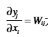가 성립하므로, 이를 위 식에 대입하면 다음처럼 됨   
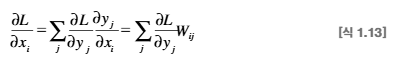   
- 이 식에서 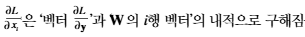을 알 수 있음   
- 그렇다면 이 관계로부터 다음 식을 유도할 수 있음   
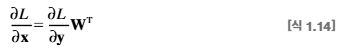   
- 이 식에서 알 수 있듯, 은 행렬의 곱을 사용해 단번에 구할 수 있음   
- 여기서 T는 전치행렬이라는 뜻
- 그럼 이 식에 대해 '형상 확인'을 해보면, 그 결과는 아래 그림과 같음   
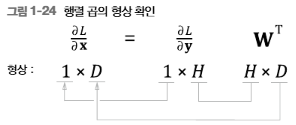   
- 그림에서 행렬의 형상이 올바름을 알 수 있음
- 따라서 위 식이 올바른 계산임을 확인할 수 있음   
- 또, 이를 역으로 취해(그 정합성이 성립되게 함으로써), 역전파의 수식(구현)을 유도할 수도 있는데, 이 방법도 y = xW라는 행렬 곱 계산을 예로 설명함
- 다만, 이번에는 미니배치 처리를 고려해 x에는 N개의 데이터가 담겨 있다고 가정함
- 그러면 x, W, y의 형상은 각각 N X D, D X H, N X H가 되어, 역전파의 계산 그래프는 아래 그림처럼 됨   
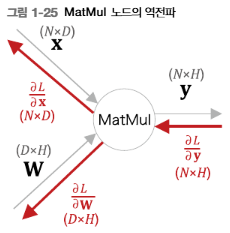   
- 이제 은 어떻게 계산할지 생각해보면
- 이때 과 관련된 변수(행렬)는 상류에서의 기울기 과 W
- 여기에서 W가 관여되는 이유는 곱셈의 역전파를 생각하면 이해하기 쉬움
    - 곱셈의 역전파에서는 '순전파 시의 입력을 서로 바꾼 값'을 사용했음
    - 이와 마찬가지로 행렬의 역전파에서도 '순전파 시의 입력을 서로 바꾼 행렬'을 사용
- 그다음은 각 행렬의 형상에 주목하여 정합성이 유지되도록 행렬 곱을 조합함
- 그러면 아래 그림과 같이 행렬 곱의 역전파를 유도할 수 있음   
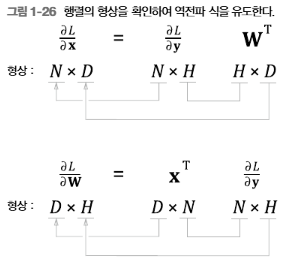   
- 그림과 같이 행렬의 형상을 확인하여 행렬 곱의 역전파 식을 유도해냄   

MatMul 노드를 하나의 계층으로 구현해보면

In [18]:
class MatMul:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.x = None
    
    def forward(self, x):
        W, = self.params
        out = np.matmul(x, W)
        self.x = x
        return out
    
    def backward(self, dout):
        W, = self.params
        dx = np.matmul(dout, W.T)
        dW = np.matmul(self.x.T, dout)
        self.grads[0][...] = dW
        return dx

- MatMul 계층은 학습하는 매개변수를 params에 보관함
- 그리고 거기에 대응시키는 형태로, 기울기는 grads에 보관함
- 역전파에서는 dx와 dW를 구해 가중치의 기울기를 인스턴스 변수인 grads에 저장함
- 참고로, 기울기 값을 설정하는 grads[0][...] = dW 코드에서 점 3개로 이루어진 생략(ellipsis)기호(...)를 사용했음
- 이렇게 하면 넘파이 배열이 가리키는 메모리 위치를 고정시킨 다음, 그 위치에 원소들을 덮어씀   

> grads[0] = dW처럼 '할당'해도 되지만, '생략 기호'는 넘파이 배열의 '덮어쓰기'를 수행함   
> 결국 얕은 복사(shallow copy)냐 깊은 복사(deep copy)냐의 차이   
> grads[0] = dW처럼 그냥 할당하면 '얕은 복사'가 이뤄지고, grads[0][...] = dW처럼 덮어쓰면 '깊은 복사'가 이뤄짐   

생략 기호가 등장하면서 조금 복잡해졌으니 구체적인 예를 보며 설명   

In [19]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

- 넘파이 배열 a와 b가 있음
- 이 상태에서 a = b와 a[...] = b 모두 a에는 [4, 5, 6]이 할당됨   
- 그러나 두 경우에 a가 가리키는 메모리의 위치는 서로 다른데, 메모리를 단순화해 시각화하면 아래 그림처럼 됨   
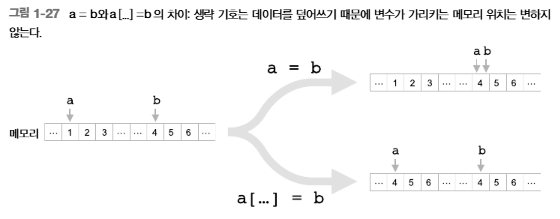   
- 그림처럼 a = b에서는 a가 가리키는 메모리 위치가 b가 가리키는 위치와 같아짐
    - 실제 데이터(4, 5, 6)는 복제되지 않는다는 뜻으로 이를 '얕은 복사'라고 함
- a[...] = b일 때는 a의 메모리 위치는 변하지 않고, 대신 a가 가리키는 메모리에 b의 원소가 복제됨
    - 실제 데이터가 복제된다는 뜻에서 이 방식을 '깊은 복사'라고 함   

이상에서 '생략 기호'를 이용하여 변수의 메모리 주소를 고정할 수 있음을 알았음(앞의 예에서 a의 주소는 고정되어 있음)   
우리의 경우 이처럼 메모리 주소를 고정함으로써 인스턴스 변수 grads를 다루기가 더 쉬워짐   

> grads 리스트에는 각 매개변수의 기울기를 저장함   
> 이때 grads 리스트의 각 원소는 넘파이 배열이며, 계층을 생성할 때 한 번만 생성함   
> 그 후로는 항상 '생략 기호'를 이용하므로, 이 넘파이 배열의 메모리 주소가 변하는 일 없이 항상 값을 덮어씀   
> 이렇게 하면 기울기를 그룹화하는 작업을 최초에 한 번만 하면 된다는 이점이 생김   

### 기울기 도출과 역전파 구현

이번 절에서는 Sigmoid 계층, 완전연결계층의 Affine 계층, Softmax with Loss 계층을 구현함


#### Sigmoid 계층

시그모이드 함수를 수식으로 쓰면   
   
그리고 그 미분은   
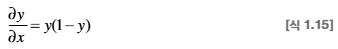   
- 이 미분식으로부터 Sigmoid 계층의 계산 그래프를 그리면 아래와 같음   
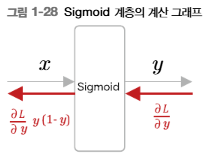   
- 보다시피 출력 쪽 계층으로부터 전해진 기울기()에 시그모이드 함수의 미분(), 즉 y(1-y)를 곱하고, 그 값을 입력 쪽 계층으로 전파함   

시그모이드 함수의 미분을 구하는 과정을 알아보면   
- 우선 시그모이드 함수의 식은   
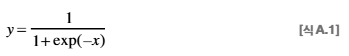   
- 이 식을 계선 그래프로 나타내면   
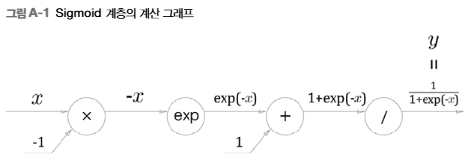   
- 그림에는 'X'와 '+' 노드 외에 'exp'와 '/' 노드도 보임
- 'exp' 노드는 y = exp(x) 계산을 수행하고, '/' 노드는 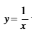을 계산함
- 지금부터 계산 그래프를 활용하여 하나씩 확인하면서 역전파를 진행해봄   

##### 1단계

'/' 노드는 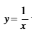을 뜻하며, 이 미분을 해석적으로 쓰면 다음 식이 됨   
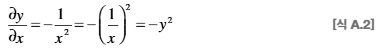   
- 위 식에서 보듯 역전파 시에는 상류의 기울기에 -y^2(순전파 출력의 제곱에 마이너스를 붙인값)을 곱하여 하류로 흘려보냄   
- 계산 그래프로는 아래 그림처럼 됨   
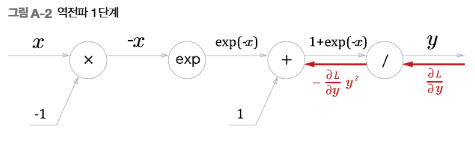   

##### 2단계

'+' 노드는 상류의 값을 그대로 하류로 흘림   
계산 그래프로는 아래 그림처럼 됨    
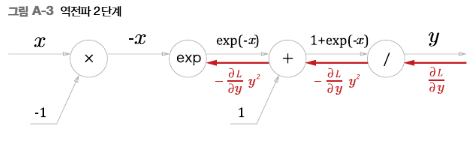   

##### 3단계

'exp' 노드는 y = exp(x)를 뜻하고, 그 미분은 다음 식과 같음   
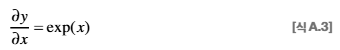   
- 계산 그래프에서는 상류의 기울기에 순전파 시의 출력(여기서는 exp(-x))을 곱하여 하류로 흘림   
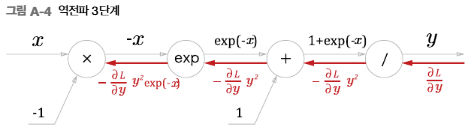   

##### 4단계

'X' 노드는 순전파 시의 입력을 서로 바꾼 값을 곱해줌   
따라서 여기에서는 -1을 곱함   
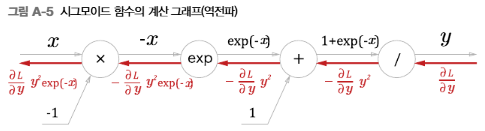   

이상으로 계산 그래프를 활용해 위 그림과 같이 sigmoid 계층의 역전파를 수행할 수 있었음   
그림의 결과로부터 역전파의 출력은 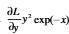가 되며, 이 값을 하류 노드로 전파하게 됨   
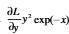은 다음과 같이 정리해서 쓸 수 있음   
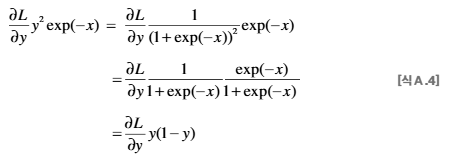   
- 이와 같은 식 전개를 통해 시그모이드 함수의 역전파는 순전파 시의 출력만으로 계산할 수 있음을 알 수 있음   
- 이상을 정리하면 시그모이드 함수의 계산 그래프는 아래 그림처럼 그릴 수 있음   
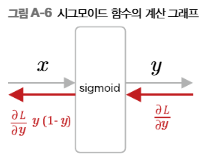   


그럼 Sigmoid 계층을 파이썬으로 구현해보면

In [20]:
class Sigmoid:
    def __init__(self):
        self.params, self.grads = [], []
        self.out = None
    
    def forward(self, x):
        out = 1 / (1 + np.exp(-x))
        self.out = out
        return out
    
    def backward(self, dout):
        dx = dout * (1.0 - self.out) * self.out
        return dx

- 순전파 때는 출력을 인스턴스 변수 out에 저장하고, 역전파를 계산할 때 이 out 변수를 사용하는 것을 볼 수 있음


#### Affine 계층

앞에서와 같이 Affine 계층의 순전파는 y = np.matmul(x, W) + b로 구현할 수 있음   
여기서 편향을 더할 때는 넘파이의 브로드캐스트가 사용됨   
그 점을 명시적으로 나타내면 Affine 계층의 계산 그래프는 아래 그림처럼 그릴 수 있음   
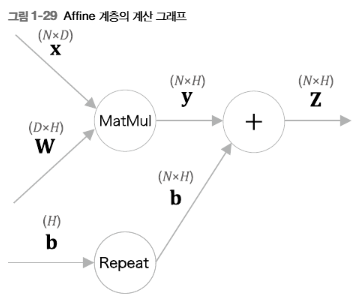   
- 그림처럼 MatMul 노드로 행렬 곱을 계산함
- 그리고 편향은 Repeat 노드에 의해 복제된 후 더해짐 (Repeat 노드가 수행하는 복제가 넘파이의 브로드캐스트 기능에 해당함)   

Affine 계층을 파이썬으로 구현해보면

In [21]:
class Affine:
    def __init__(self, W, b):
        self.params = [W, b]
        self.grads = [np.zeros_like(W), np.zeros_like(b)]
        self.x = None
    
    def forward(self, x):
        W, b = self.params
        out = np.matmul(x, W) + b
        self.x = x
        return out
    
    def backward(self, dout):
        W, b = self.params
        dx = np.matmul(dout, W.T)
        dW = np.matmul(self.x.T, dout)
        db = np.sum(dout, axis=0)

        self.grads[0][...] = dW
        self.grads[1][...] = db
        return dx

- 이 책의 구현 규칙에 따라 인스턴스 변수 params에는 매개변수를, grads에는 기울기를 저장함
- Affine의 역전파는 Matmul 노드와 Repeat 노드의 역전파를 수행하면 구할 수 있음
- Repeat 노드의 역전파는 np.sum() 메서드로 계산할 수 있는데, 이때 행렬의 형상을 잘 살펴보고 어느 축(axis)으로 합을 구할지를 명시해야 함   
- 마지막으로, 가중치 매개변수의 기울기를 인스턴스 변수 grads에 저장함   

> Affine 계층은 이미 구현한 MatMul 계층을 이용하면 더 쉽게 구현할 수 있음   
> 이번 절에서는 미리 구현해둔 MatMul 계층을 이용하지 않고, 넘파이의 메서드를 사용해 구현했음   


#### Softmax with Loss 계층

소프트맥스 함수와 교차 엔트로피 오차는 Softmax with Loss라는 하나의 계층으로 구현   
먼저 이 계층의 계산 그래프는   
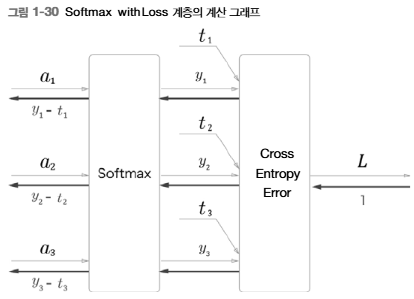   
- 이 계산 그래프에서는 소프트맥스 함수는 Softmax 계층으로, 교차 엔트로피 오차는 Cross Entropy Error 계층으로 표기함
- 그리고 3-클래스 분류를 가정하여 이전 계층(입력층에 가까운 계층)으로부터 3개의 입력을 받도록 함   
- 그림처럼 Softmax 계층은 입력 (a1, a2, a3)를 정규화하여 (y1, y2, y3)를 출력함
- 그리고 Cross Entropy Error 계층은 Softmax의 출력 (y1, y2, y3)와 정답 레이블 (t1, t2, t3)를 받고, 이 데이터로부터 손실 L을 구해 출력함   

> 그림에서 주목할 부분은 역전파의 결과   
> Softmax 계층의 역전파는 (y1-t1, y2-t2, y3-t3)로 깔끔하게 떨어짐   
> (y1, y2, y3)는 Softmax 계층의 출력이고, (t1, t2, t3)는 정답 레이블이므로, Softmax 계층의 역전파는 자신의 출력과 정답 레이블의 차이라는 뜻   
> 이처럼 신경망의 역전파는 이 차이(오차)를 앞 계층에 전해주는 것으로, 신경망 학습에서 아주 중요한 성질   

Softmax with Loss 계층을 구현해보면

In [22]:
def softmax(x):
    if x.ndim == 2:
        x = x - x.max(axis=1, keepdims=True)
        x = np.exp(x)
        x /= x.sum(axis=1, keepdims=True)
    elif x.ndim == 1:
        x = x - np.max(x)
        x = np.exp(x) / np.sum(np.exp(x))

    return x


def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)
        
    # 정답 데이터가 원핫 벡터일 경우 정답 레이블 인덱스로 변환
    if t.size == y.size:
        t = t.argmax(axis=1)
             
    batch_size = y.shape[0]

    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

class SoftmaxWithLoss:
    def __init__(self):
        self.params, self.grads = [], []
        self.y = None  # softmax의 출력
        self.t = None  # 정답 레이블

    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)

        # 정답 레이블이 원핫 벡터일 경우 정답의 인덱스로 변환
        if self.t.size == self.y.size:
            self.t = self.t.argmax(axis=1)

        loss = cross_entropy_error(self.y, self.t)
        return loss

    def backward(self, dout=1):
        batch_size = self.t.shape[0]

        dx = self.y.copy()
        dx[np.arange(batch_size), self.t] -= 1
        dx *= dout
        dx = dx / batch_size

        return dx

### 가중치 갱신

오차역전파법으로 기울기를 구했으면, 그 기울기를 사용해 신경망의 매개변수를 갱신함   
이때 신경망의 학습은 다음 순서로 수행함   
- 1단계: 미니배치
    - 훈련 데이터 중에서 무작위로 다수의 데이터를 골라냄
- 2단계: 기울기 계산
    - 오차역전파법으로 각 가중치 매개변수에 대한 손실 함수의 기울기를 구함
- 3단계: 매개변수 갱신
    - 기울기를 사용하여 가중치 매개변수를 갱신
- 4단계: 반복
    - 1 ~ 3단계를 필요한 만큼 반복   

이러한 단계를 거쳐 신경망 학습이 이루어짐   
우선 미니배치에서 데이터를 선택하고, 이어서 오차역전파법으로 가중치의 기울기를 얻음   
이 기울기는 현재의 가중치 매개변수에서 손실을 가장 크게 하는 방향을 가리킴   
따라서 매개변수를 그 기울기와 반대 방향으로 갱신하면 손실을 줄일 수 있음   
이것이 **경사하강법(Gradient Descent)**   
그런 다음 이상의 작업을 필요한 만큼 반복함   

3단계에서 수행하는 가중치 갱신 기법의 종류는 아주 다양한데, 여기에서는 그중 가장 단순한 **확률적경사하강법(Stochastic Gradient Descent(SGD))** 을 구현함   
'확률적'은 무작위로 선택된 데이터(미니배치)에 대한 기울기를 이용한다는 뜻   

SGD는 단순한 방법   
(현재의) 가중치를 기울기 방향으로 일정한 거리만큼 갱신함   
수식으로는   
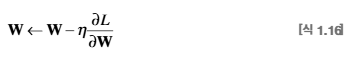   
- 이 식에서 갱신하는 가중치 매개변수가 W이고, W에 대한 손실 함수의 기울기가    
- **𝜂(에타)** 는 학습률(learning rate)를 나타내며, 실제로는 0.01이나 0.001 같ㅇ느 값을 미리 정해 사용함   

그럼 SGD를 파이썬으로 구현하기   
여기에서는 모듈화를 고려하여 매개변수를 갱신할 클래스를 구현해놓음(SGD 외에도 AdaGrad와 Adam도 있음)   

그리고 매개변수를 갱신하는 클래스는 update(params, grads)라는 공통 메서드를 갖도록 구현함   
이 메서드의 인수 params에는 신경망의 가중치가, grads에는 기울기가 각각 리스트로 저장되어 있어야 함   
그리고 params와 grads 리스트에는 대응하는 매개변수와 기울기가 같은 위치(인덱스)에 저장되어 있다고 가정함   
그러면 SGD는 다음과 같이 구현할 수 있음

In [23]:
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr

    def update(self, params, grads):
        for i in range(len(params)):
            params[i] -= self.lr * grads[i]

- 초기화 인수 lr은 학습률을 뜻하며, 그 값을 인스턴스 변수로 저장해둠   
- 그리고 update(params, grads) 메서드는 매개변수 갱신을 처리함

이 SGD 클래스를 사용하면 신경망의 매개변수 갱신을 다음처럼 할 수 있음 (실제로는 동작하지 않는 의사 코드)

In [24]:
'''
model = TwoLayerNet(...)
optimizer = SGD()

for i in range(10000):
    ...
    x_batch, t_batch = get_mini_batch(...)  # 미니배치 획득
    loss = model.forward(x_batch, t_batch)
    model.backward()
    optimizer.update(model.params, model.grads)
    ...
'''

'\nmodel = TwoLayerNet(...)\noptimizer = SGD()\n\nfor i in range(10000):\n    ...\n    x_batch, t_batch = get_mini_batch(...)  # 미니배치 획득\n    loss = model.forward(x_batch, t_batch)\n    model.backward()\n    optimizer.update(model.params, model.grads)\n    ...\n'

- 이처럼 최적화를 수행하는 클래스를 분리해 구현함으로써 기능을 쉽게 모듈화할 수 있게 했음
- 이 책에서는 SGD 외에도 Momentum, AdaGrad, Adam 등의 기법을 구현하여두었음   

In [25]:
class Momentum:
    '''
    모멘텀 SGG(Momentum SGD)
    '''
    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None
        
    def update(self, params, grads):
        if self.v is None:
            self.v = []
            for param in params:
                self.v.append(np.zeros_like(param))

        for i in range(len(params)):
            self.v[i] = self.momentum * self.v[i] - self.lr * grads[i]
            params[i] += self.v[i]


class AdaGrad:
    '''
    AdaGrad
    '''
    def __init__(self, lr=0.01):
        self.lr = lr
        self.h = None
        
    def update(self, params, grads):
        if self.h is None:
            self.h = []
            for param in params:
                self.h.append(np.zeros_like(param))

        for i in range(len(params)):
            self.h[i] += grads[i] * grads[i]
            params[i] -= self.lr * grads[i] / (np.sqrt(self.h[i]) + 1e-7)


class Adam:
    '''
    Adam (http://arxiv.org/abs/1412.6980v8)
    '''
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.iter = 0
        self.m = None
        self.v = None
        
    def update(self, params, grads):
        if self.m is None:
            self.m, self.v = [], []
            for param in params:
                self.m.append(np.zeros_like(param))
                self.v.append(np.zeros_like(param))
        
        self.iter += 1
        lr_t = self.lr * np.sqrt(1.0 - self.beta2**self.iter) / (1.0 - self.beta1**self.iter)

        for i in range(len(params)):
            self.m[i] += (1 - self.beta1) * (grads[i] - self.m[i])
            self.v[i] += (1 - self.beta2) * (grads[i]**2 - self.v[i])
            
            params[i] -= lr_t * self.m[i] / (np.sqrt(self.v[i]) + 1e-7)

## 신경망으로 문제를 풀다

준비는 끝났고 지금부터 간단한 데이터셋으로 신경망을 학습시키기

### 스파이럴 데이터셋

이 책에서는 데이터셋을 다루는 편의 클래스 몇 개를 dataset 디렉터리에 준비해둠   
이번 절에서는 그중 dataset/spiral.py 파일을 이용   
이 파일에는 ‘스파이럴(spiral, 나선형의 데이터)’를 읽어 들이는 클래스가 구현되어 있으며, 다음과 같이 사용함

In [26]:
import sys
sys.path.append('..')  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
from dataset import spiral 

import matplotlib.pyplot as plt

x, t = spiral.load_data()
print('x', x.shape)
print('t', t.shape)

x (300, 2)
t (300, 3)


- 이 예에서는 spiral.py를 임포트하여 이용함  
- spiral.load_data( )가 데이터를 읽어 옴
- 이때 x가 입력 데이터이고, t가 정답 레이블
- x와 t의 형상을 출력해보면 각각 300개의 샘플 데이터를 담고 있으며, x는 2차원 데이터이고 t는 3차원 데이터임을 알 수 있음
- 참고로 t는 원핫 벡터로, 정답에 해당하는 클래스에는 1이, 그 외에는 0이 레이블되어 있음   

이 데이터가 어떤 모습인지 그래프로 그려보면   
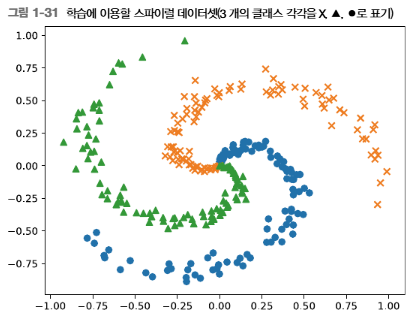   
- 그림처럼 입력은 2차원 데이터이고, 분류할 클래스 수는 3개가 있음   
- 이 그래프를 보면 직선만으로는 클래스들을 분리할 수 없음을 알 수 있음   
- 따라서 비선형 분리를 학습해야 함
- (비선형인 시그모이드 함수를 활성화 함수로 사용하는 은닉층이 있는) 우리의 신경망은 이 비선형 패턴을 올바르게 학습할 수 있는지?   

> 실전에서는 데이터셋을 훈련용과 테스트용 (그리고 검증용) 데이터로 분리하여 학습과 평가를 수행하지만, 여기에서는 실험을 간단히 하기 위해 이 작업은 생략

### 신경망 구현

그럼 신경망을 구현해보기   
이번 절에서는 은닉층이 하나인 신경망을 구현함   

먼저 초기화를 담당하는 \_\_init__부터 보면

In [ ]:
import sys
sys.path.append('..')  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import numpy as np
from common.layers import Affine, Sigmoid, SoftmaxWithLoss


class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size):
        I, H, O = input_size, hidden_size, output_size

        # 가중치와 편향 초기화
        W1 = 0.01 * np.random.randn(I, H)
        b1 = np.zeros(H)
        W2 = 0.01 * np.random.randn(H, O)
        b2 = np.zeros(O)

        # 계층 생성
        self.layers = [
            Affine(W1, b1),
            Sigmoid(),
            Affine(W2, b2)
        ]
        self.loss_layer = SoftmaxWithLoss()

        # 모든 가중치와 기울기를 리스트에 모음
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def predict(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def forward(self, x, t):
        score = self.predict(x)
        loss = self.loss_layer.forward(score, t)
        return loss

    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

- 초기화 메서드는 3개의 인수를 받는데, 차례대로 input_size는 입력층의 뉴런 수, hidden_size는 은닉층의 뉴런 수, output_size는 출력층의 뉴런 수
- 메서드 안에서는 우선 편향을 영벡터(zero vector)로 초기화하고(np.zeros( )), 가중치는 작은 무작위 값으로 초기화함(0.01 * np.random.randn( ))
- 참고로 가중치를 작은 무작위 값으로 설정하면 학습이 잘 진행될 가능성이 커짐
- 계속해서 필요한 계층을 생성해 인스턴스 변수인 layers 리스트에 모아두고, 마지막으로 이 모델에서 사용하는 매개변수들과 기울기들을 각각 하나로 모음   

> Softmax with Loss 계층은 다른 계층과 다르게 취급하여, layers 리스트가 아닌 loss_layer 인스턴스 변수에 별도로 저장함   

이어서 TwoLayerNet에 3개의 메서드를 구현해 넣음   
추론을 수행하는 predict() 메서드, 순전파를 담당하는 forward() 메서드, 역전파를 담당하는 backward() 메서드  

In [27]:
import sys
sys.path.append('..')  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import numpy as np
from common.layers import Affine, Sigmoid, SoftmaxWithLoss


class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size):
        I, H, O = input_size, hidden_size, output_size

        # 가중치와 편향 초기화
        W1 = 0.01 * np.random.randn(I, H)
        b1 = np.zeros(H)
        W2 = 0.01 * np.random.randn(H, O)
        b2 = np.zeros(O)

        # 계층 생성
        self.layers = [
            Affine(W1, b1),
            Sigmoid(),
            Affine(W2, b2)
        ]
        self.loss_layer = SoftmaxWithLoss()

        # 모든 가중치와 기울기를 리스트에 모음
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def predict(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def forward(self, x, t):
        score = self.predict(x)
        loss = self.loss_layer.forward(score, t)
        return loss

    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

- 보다시피 이번 구현은 이전보다 깔끔함
- 신경망에서 사용하는 처리 블록들을 ‘계층’ 단위로 미리 구현해놨으므로, 여기에서는 그 계층들의 forward()와 backward()를 적절한 순서로 호출만 하면 되기 때문

### 학습용 코드

이어서 학습을 수행하는 코드를 보면   
여기에서는 학습 데이터를 읽어 들여 신경망(모델)과 옵티마이저(최적화기)를 생성함   
그리고 앞 절에서 본 학습의 네 단계의 절차대로 학습을 수행함   
참고로 머신러닝 분야에서는 문제를 풀기 위해서 설계한 기법(신경망이나 SVM(서포트 벡터 머신) 등)을 가리켜 보통 '모델'이라고 부름

| 에폭 1 |  반복 10 / 10 | 손실 1.13
| 에폭 2 |  반복 10 / 10 | 손실 1.13
| 에폭 3 |  반복 10 / 10 | 손실 1.12
| 에폭 4 |  반복 10 / 10 | 손실 1.12
| 에폭 5 |  반복 10 / 10 | 손실 1.11
| 에폭 6 |  반복 10 / 10 | 손실 1.14
| 에폭 7 |  반복 10 / 10 | 손실 1.16
| 에폭 8 |  반복 10 / 10 | 손실 1.11
| 에폭 9 |  반복 10 / 10 | 손실 1.12
| 에폭 10 |  반복 10 / 10 | 손실 1.13
| 에폭 11 |  반복 10 / 10 | 손실 1.12
| 에폭 12 |  반복 10 / 10 | 손실 1.11
| 에폭 13 |  반복 10 / 10 | 손실 1.09
| 에폭 14 |  반복 10 / 10 | 손실 1.08
| 에폭 15 |  반복 10 / 10 | 손실 1.04
| 에폭 16 |  반복 10 / 10 | 손실 1.03
| 에폭 17 |  반복 10 / 10 | 손실 0.96
| 에폭 18 |  반복 10 / 10 | 손실 0.92
| 에폭 19 |  반복 10 / 10 | 손실 0.92
| 에폭 20 |  반복 10 / 10 | 손실 0.87
| 에폭 21 |  반복 10 / 10 | 손실 0.85
| 에폭 22 |  반복 10 / 10 | 손실 0.82
| 에폭 23 |  반복 10 / 10 | 손실 0.79
| 에폭 24 |  반복 10 / 10 | 손실 0.78
| 에폭 25 |  반복 10 / 10 | 손실 0.82
| 에폭 26 |  반복 10 / 10 | 손실 0.78
| 에폭 27 |  반복 10 / 10 | 손실 0.76
| 에폭 28 |  반복 10 / 10 | 손실 0.76
| 에폭 29 |  반복 10 / 10 | 손실 0.78
| 에폭 30 |  반복 10 / 10 | 손실 0.75
| 에폭 31 |  반복 10 / 10 | 손실 0.78
| 에폭 32 |  반복 10 

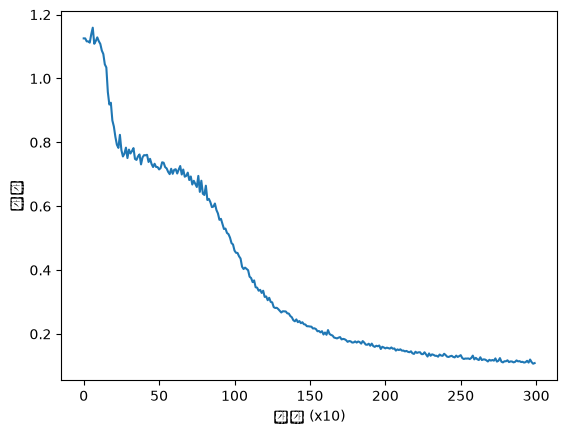

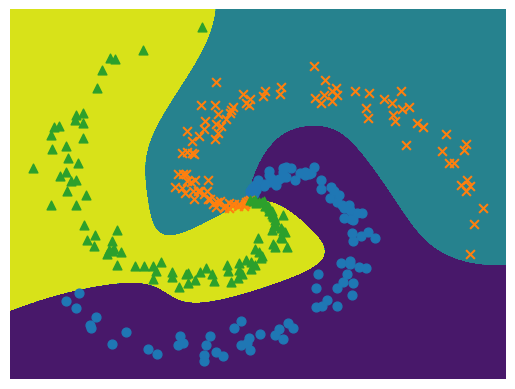

In [31]:
import sys
sys.path.append('..')  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import numpy as np
from common.optimizer import SGD
from dataset import spiral
import matplotlib.pyplot as plt


# 하이퍼파라미터 설정
max_epoch = 300
batch_size = 30
hidden_size = 10
learning_rate = 1.0

# 데이터 읽기, 모델과 옵티마이저 생성
x, t = spiral.load_data()
model = TwoLayerNet(input_size=2, hidden_size=hidden_size, output_size=3)
optimizer = SGD(lr=learning_rate)

# 학습에 사용하는 변수
data_size = len(x)
max_iters = data_size // batch_size
total_loss = 0
loss_count = 0
loss_list = []

for epoch in range(max_epoch):
    # 데이터 뒤섞기
    idx = np.random.permutation(data_size)
    x = x[idx]
    t = t[idx]

    for iters in range(max_iters):
        batch_x = x[iters*batch_size:(iters+1)*batch_size]
        batch_t = t[iters*batch_size:(iters+1)*batch_size]

        # 기울기를 구해 매개변수 갱신
        loss = model.forward(batch_x, batch_t)
        model.backward()
        optimizer.update(model.params, model.grads)

        total_loss += loss
        loss_count += 1

        # 정기적으로 학습 경과 출력
        if (iters+1) % 10 == 0:
            avg_loss = total_loss / loss_count
            print('| 에폭 %d |  반복 %d / %d | 손실 %.2f'
                  % (epoch + 1, iters + 1, max_iters, avg_loss))
            loss_list.append(avg_loss)
            total_loss, loss_count = 0, 0


# 학습 결과 플롯
plt.plot(np.arange(len(loss_list)), loss_list, label='train')
plt.xlabel('반복 (x10)')
plt.ylabel('손실')
plt.show()

# 경계 영역 플롯
h = 0.001
x_min, x_max = x[:, 0].min() - .1, x[:, 0].max() + .1
y_min, y_max = x[:, 1].min() - .1, x[:, 1].max() + .1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
X = np.c_[xx.ravel(), yy.ravel()]
score = model.predict(X)
predict_cls = np.argmax(score, axis=1)
Z = predict_cls.reshape(xx.shape)
plt.contourf(xx, yy, Z)
plt.axis('off')

# 데이터점 플롯
x, t = spiral.load_data()
N = 100
CLS_NUM = 3
markers = ['o', 'x', '^']
for i in range(CLS_NUM):
    plt.scatter(x[i*N:(i+1)*N, 0], x[i*N:(i+1)*N, 1], s=40, marker=markers[i])
plt.show()

1. 우선 하이퍼파라미터(hyperparameter)를 설정함
    - 구체적으로는 학습하는 에폭 수, 미니배치 크기, 은닉층의 뉴런 수, 학습률을 설정함
2. 계속해서 데이터를 읽어 들이고, 신경망(모델)과 옵티마이저를 생성함
    - 우리는 이미 2층 신경망을 TwoLayerNet 클래스로, 또 옵티마이저를 SGD 클래스로 구현해놨으니, 여기에서는 이 클래스들을 이용   

> 에폭(epoch)은 학습 단위   
> 1에폭은 학습 데이터를 모두 '살펴본' 시점(데이터셋을 1바퀴 돌아본 시점)을 뜻함   
> 이 코드에서는 300에폭을 학습함   

학습은 미니배치 방식으로 진행되며 데이터를 무작위로 선택함   

3. 여기에서는 에폭 단위로 데이터를 뒤섞고, 뒤섞은 데이터 중 앞에서부터 순서대로 뽑아내는 방식을 사용함    
    - 데이터 뒤섞기(정확하게는 데이터의 '인덱스' 뒤섞기)에는 np.random.permutation( ) 메서드를 사용함   
    - 이 메서드에 인수로 N을 주면, 0에서 N-1까지의 무작위 순서를 생성해 반환함   
    - 실제 사용 예는 다음과 같음

In [33]:
import numpy as np

print(np.random.permutation(10))
print(np.random.permutation(10))

[8 6 0 1 7 4 2 9 3 5]
[8 2 9 1 3 7 5 0 4 6]


이처럼 np.random.permutation()을 호출하면 데이터 인덱스를 무작위로 뒤섞을 수 있음   

4. 계속해서 기울기를 구해 매개변수를 갱신함   
5. 마지막으로, 정기적으로 학습 결과를 출력함   
    - 이 코드에서는 10번째 반복마다 손실의 평균을 구해 loss_list 변수에 추가함


이상으로 학습을 수행하는 코드를 살펴봤음   

> 여기서 구현한 신경망의 학습 코드는 이 책의 다른 장소에서도 사용함   
> 그래서 이 코드를 Trainer 클래스로 만들어뒀음   
> 신경망 학습의 상세 내용을 이 클래스 안으로 밀어넣은 것   

위에서 코드를 실행해보면 터미널에 출력되는 손실 값이 순조롭게 낮아지는 것을 알 수 있음   
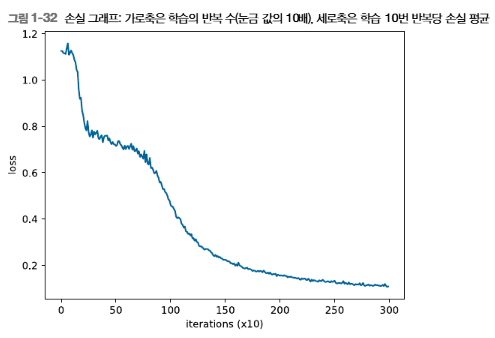   
- 그림에서 보듯, 학습을 진행함에 따라 손실이 줄어들고 있음   
- 우리 신경망이 올바른 방향으로 학습되고 있는 것   
- 학습 후 신경망이 영역을 어떻게 분리했는지 시각화해보면 (이를 **결정 경계(decision boundary)라고 함)   
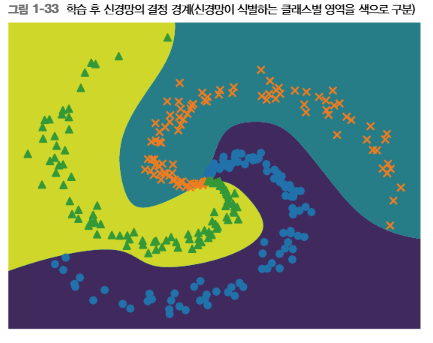   
- 그림에서 보듯학습된 신경망은 '나선형' 패턴을 올바르게 파악했음을 알 수 있음
- 즉, 비선형 분리 영역을 학습할 수 있었음
- 이처럼 신경망에 은닉층을 추가하면 더 복잡한 표현이 가능해짐
- 층을 더 깊게 쌓으면 표현력 또한 더 풍부해지는 것이 딥러닝의 특징

### Trainer 클래스

이 책에서는 학습을 수행하는 역할을 Trainer라는 클래스로 제공함   
내요은 앞 절의 소스 코드와 거의 같음   
새로운 기능이 몇개 있는데, 자세한 사용법은 뒤에서 설명   

이 클래스의 초기화 메서드는 신경망(모델)과 옵티마이저를 인수로 받음   
구체적으로는 다음과 같이 사용함

In [34]:
'''
model = TwoLayerNet(...)
optimizer = SGD(lr=1.0)
trainer = Trainer(model, optimizer)
'''

'\nmodel = TwoLayerNet(...)\noptimizer = SGD(lr=1.0)\ntrainer = Trainer(model, optimizer)\n'

- 그리고 fit( ) 메서드를 호출해 학습을 시작함
- 이 fit() 메서드가 받는 인수는 다음과 같음   
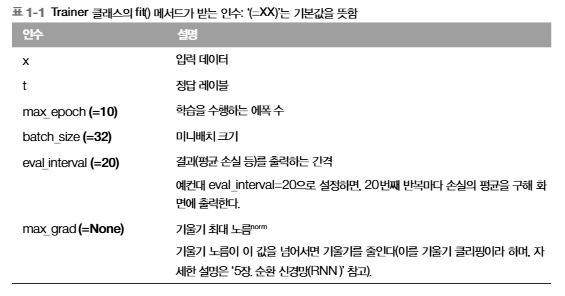   
- Trainer 클래스는 plot() 메서드도 제공함   
- 이 메서드는 fit()에서 기록한 손실(정확하게는 eval_interval 시점에 평가된 평균 손실)을 그래프로 그려줌   

이제 Trainer 클래스를 사용해 학습을 수행하는 코드를 보면

| 에폭 1 |  반복 1 / 10 | 시간 0[s] | 손실 1.10
| 에폭 2 |  반복 1 / 10 | 시간 0[s] | 손실 1.12
| 에폭 3 |  반복 1 / 10 | 시간 0[s] | 손실 1.13
| 에폭 4 |  반복 1 / 10 | 시간 0[s] | 손실 1.12
| 에폭 5 |  반복 1 / 10 | 시간 0[s] | 손실 1.12
| 에폭 6 |  반복 1 / 10 | 시간 0[s] | 손실 1.10
| 에폭 7 |  반복 1 / 10 | 시간 0[s] | 손실 1.14
| 에폭 8 |  반복 1 / 10 | 시간 0[s] | 손실 1.16
| 에폭 9 |  반복 1 / 10 | 시간 0[s] | 손실 1.11
| 에폭 10 |  반복 1 / 10 | 시간 0[s] | 손실 1.12
| 에폭 11 |  반복 1 / 10 | 시간 0[s] | 손실 1.12
| 에폭 12 |  반복 1 / 10 | 시간 0[s] | 손실 1.12
| 에폭 13 |  반복 1 / 10 | 시간 0[s] | 손실 1.10
| 에폭 14 |  반복 1 / 10 | 시간 0[s] | 손실 1.09
| 에폭 15 |  반복 1 / 10 | 시간 0[s] | 손실 1.08
| 에폭 16 |  반복 1 / 10 | 시간 0[s] | 손실 1.04
| 에폭 17 |  반복 1 / 10 | 시간 0[s] | 손실 1.03
| 에폭 18 |  반복 1 / 10 | 시간 0[s] | 손실 0.94
| 에폭 19 |  반복 1 / 10 | 시간 0[s] | 손실 0.92
| 에폭 20 |  반복 1 / 10 | 시간 0[s] | 손실 0.92
| 에폭 21 |  반복 1 / 10 | 시간 0[s] | 손실 0.87
| 에폭 22 |  반복 1 / 10 | 시간 0[s] | 손실 0.85
| 에폭 23 |  반복 1 / 10 | 시간 0[s] | 손실 0.80
| 에폭 24 |  반복 1 / 10 | 시간 0[s] | 손실 0.79
| 에폭 25 |  반복 1 / 10 | 시간

c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


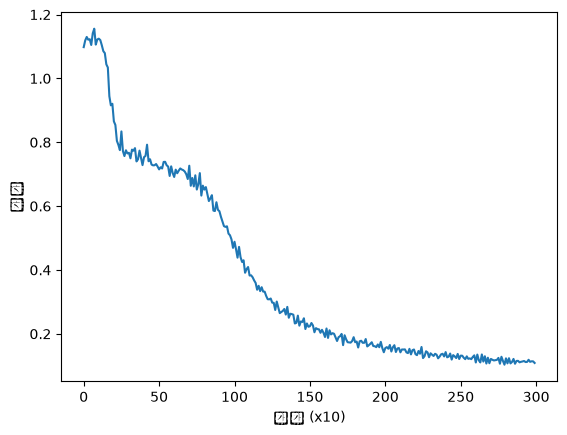

In [35]:
import sys
sys.path.append('..')  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
from common.optimizer import SGD
from common.trainer import Trainer
from dataset import spiral

# 하이퍼파라미터 설정
max_epoch = 300
batch_size = 30
hidden_size = 10
learning_rate = 1.0

x, t = spiral.load_data()
model = TwoLayerNet(input_size=2, hidden_size=hidden_size, output_size=3)
optimizer = SGD(lr=learning_rate)

trainer = Trainer(model, optimizer)
trainer.fit(x, t, max_epoch, batch_size, eval_interval=10)
trainer.plot()

- 이 코드를 실행하면 이전 절과 같은 신경망 학습이 이뤄짐
- 앞에서 본 학습용 코드를 Trainer 클래스에 맡겼기 때문에 코드가 깔끔해짐
- 이 책에서는 앞으로 학습을 해야 할 때면 항상 Trainer 클래스를 사용함

## 계산 고속화

신경망의 학습과 추론에 드는 연산량은 상당함   
그래서 신경망에서는 얼마나 빠르게 계산하느냐가 매우 중요한 주제   
그래서 이번 절에서는 신경망 고속화에 도움되는 '비트 정밀도'와 'GPU'에 관해 가볍게 설명함   

> 이 책은 속도보다는 알기 쉽게 구현하기에 우선순위를 두었음   
> 다만, 고속화의 관점에서 앞으로는 데이터의 비트 정밀도를 의식해 구현함   
> 또한, 계산이 오래 걸리는 부분에서는(선택적으로) GPU로 실행할 수 있도록 준비해둠

### 비트 정밀도

넘파이의 부동소수점 수는 기본적으로 64비트 데이터 타입을 사용합니다(독자의 환경, 즉 OS나 파이썬/넘파이 버전 등에 따라 바뀔 수 있음)   
실제로 64비트 부동소수점 수가 사용되는지는 다음 코드로 확인할 수 있음

In [37]:
import numpy as np

a = np.random.randn(3)
print(a.dtype)

float64


- 이처럼 넘파이 배열의 인스턴스 변수 dtype을 출력해 데이터 타입을 알아볼 수 있음   
- 바로 앞 결과가 출력한 float64는 64비트 부동소수점 수라는 뜻   

넘파이는 64비트 부동소수점 수를 표준으로 사용함   
그러나 신경망의 추론과 학습은 32비트 부동소수점 수로도 문제없이(인식률을 거의 떨어뜨리는 일 없이) 수행할 수 있다고 함   
32비트는 64비트의 절반이므로, 메모리 관점에서는 항상 32비트가 더 좋다고 말할 수 있음   
또, 신경망 계산 시 데이터를 전송하는 '버스 대역폭(bus bandwidth)'이 병목이 되는 경우가 왕왕 있음   
이런 경우에도 데이터 타입이 작은 게 유리함   
마지막으로 계산 속도 측면에서도 32비트 부동소수점 수가 일반적으로 더 빠름(CPU나 GPU 아키텍처에 따라 다름)   

이런 이유로 이 책에서는 32비트 부동소수점 수를 우선으로 사용함   
넘파이에서 32비트 부동소수점 수를 사용하려면 다음과 같이 데이터 타입을 np.float32나 'f'로 지정함

In [38]:
b = np.random.randn(3).astype(np.float32)
print(b.dtype)

c = np.random.randn(3).astype('f')
print(c.dtype)

float32
float32


또한 신경망 추론으로 한정하면, 16비트 부동소수점 수를 사용해도 인식률이 거의 떨어지지 않음   
그리고 넘파이에도 16비트 부동소수점 수가 준비되어 있음   
다만, 일반적으로 CPU와 GPU는 연산 자체를 32비트로 수행함   
따라서 16비트 부동소수점 수로 변환하더라도 계산 자체는 32비트로 이뤄져서 처리 속도 측면에서는 혜택이 없을 수도 있음   

그러나 학습된 가중치를 (파일에) 저장할 때는 16비트 부동소수점 수가 여전히 유효함   
가중치 데이터를 16비트로 저장하면 32비트를 쓸 때보다 절반의 용량만 사용하기 때문   
그래서 이 책에서는 학습된 가중치를 저장하는 경우에 한해 16비트 부동소수점 수로 변환함   

> 딥러닝이 주목받으면서, 최근 GPU들은 '저장'과 '연산' 모두에 16비트 반정밀도 부동소수점 수를 지원하도록 진화했음   
> 구글에서 개발한 TPU 칩은 8비트 계산도 지원함

### GPU(쿠파이)

딥러닝의 계산은 대량의 곱하기 연산으로 구성됨   
이 대량의 곱하기 연산 대부분은 병렬로 계산할 수 있는데, 바로 이 점에서는 CPU보다 GPU가 유리함   
대부분의 딥러닝 프레임워크가 CPU뿐 아니라 GPU도 지원하는 이유가 바로 이것   

이 책의 예제 중에는 쿠파이라는 파이썬 라이브러리를 사용할 수 있는 게 있음   
쿠파이는 GPU를 이용해 병렬 계산을 수행해주는 라이브러리인데, 아쉽게도 엔비디아의 GPU에서만 동작함   
또한, CUDA라는 GPU 전용 범용 병렬 컴퓨팅 · 플랫폼을 설치해야 함   
자세한 설치 방법은 쿠파이 공식 설치 가이드를 참고   

쿠파이를 사용하면 엔비디아 GPU를 사용해 간단하게 병렬 계산을 수행할 수 있음   
더욱 중요한 점은 쿠파이는 넘파이와 호환되는 API를 제공한다는 사실   
간단한 사용 예를 보면

In [40]:
import cupy as cp

x = cp.arange(6).reshape(2, 3).astype('f')
print(x)
print(x.sum(axis=1))

c:\Users\ESDL\Desktop\deeplearning\.venv\Lib\site-packages\cuda\pathfinder\_dynamic_libs\search_steps.py:196: UserWarning: Multiple CUDA environment variables are set but differ:
  CUDA_PATH=C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.9
  CUDA_HOME=C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.6
Using CUDA_PATH (highest priority).
  cuda_home = get_cuda_path_or_home()


[[0. 1. 2.]
 [3. 4. 5.]]
[ 3. 12.]


- 이와 같이 쿠파이의 사용법은 기본적으로 넘파이와 같음
- 사용법은 같지만 뒤에서 열심히 GPU를 사용해 계산하는 것
- 다시말해, 넘파이로 작성한 코드를 'GPU용'으로 변경하기 아주 쉽다는 뜻
- 그저 (보통은) numpy를 cupy로 대체해주기만 하면 끝   

> 2018년 6월 기준, 쿠파이가 넘파이의 모든 메서드를 지원하는 건 아님   
> 쿠파이는 넘파이와 100% 호환되지는 않지만, 공통된 API를 많이 제공함   

이 책에서는 이해하기 쉽게 구현하는 걸 우선하므로 기본적으로는 CPU에서 수행되는 코드로 작성함   
그러나 계산이 오래 걸리는 코드는 선택적으로 쿠파이를 사용한 구현도 제공함   

## 정리

이번 장에서는 신경망의 기본을 복습했음   
벡터와 행렬 같은 수학 개념부터 시작해서 파이썬(특히 넘파이)의 기본적인 사용법을 확인했음   
그런 다음 신경망의 구조를 살펴봤음   
특히 계산 그래프의 기본 부품(덧셈 노드와 곱셈 노드 등)을 몇 개 사용하여 순전파와 역전파를 설명했음   

또한 간단한 신경망도 구현해봤음   
모듈화를 고려해 신경망의 기본 구성요소를 계층으로 구현했음   
계층을 구현할 때는 모든 클래스가 forward()와 backward() 메서드를 제공하고, params와 grads라는 인스턴스 변수를 갖는다는 '구현 규칙'을 따랐음   
이 규칙 덕분에 앞으로의 신경망 구현이 훨씬 쉬워짐   

마지막으로 인공적인 '스파이럴 데이터셋'을 활용해 은닉층이 한 개인 신경망을 학습시키고, 그 모델이 올바르게 학습되었음을 확인했음   

### 이번 장에서 배운 내용

- 신경망은 입력층, 은닉층(중간층), 출력층을 지님
- 완전연결계층에 의해 선형 변환이 이뤄지고, 활성화 함수에 의해 비선형 변환이 이뤄짐
- 완전연결계층이나 미니배치 처리는 행렬로 모아 한꺼번에 계산할 수 있음
- 오차역전파법을 사용하여 신경망의 손실에 관한 기울기를 효율적으로 구할 수 있음
- 신경망이 수행하는 처리는 계산 그래프로 시각화할 수 있으며, 순전파와 역전파를 이해하는 데 도움이 됨
- 신경망의 구성요소들을 ‘계층’으로 모듈화해두면, 이를 조립하여 신경망을 쉽게 구성할 수 있음
- 신경망 고속화에는 GPU를 이용한 병렬 계산과 데이터의 비트 정밀도가 중요함